# B-Scan Migration Playground – Subwavelength PSF **Vertical** TimeLapse Analysis

**Purpose:** Quantify the detection limit of **vertical** (depth) subwavelength scatterer movement using three migration methods.

A single PEC cylinder at **x = 2.0 m** (centre of the survey domain) sinks downward from its baseline depth (y = 0.224 m in gprMax coordinates, i.e. 0.676 m below the ice surface) by fractions of the wavelength: 1λ, ½λ, ¼λ, ⅛λ, ¹⁄₁₆λ, ¹⁄₃₂λ.  The 2λ scenario is omitted because it would push the scatterer below the domain floor.

Methods tested:
- **Kirchhoff** delay-and-sum (PyLops zero-offset operator)
- **Gazdag** phase-shift (f-k domain, exploding-reflector half-velocity)
- **Back-propagation** time-reversal (gprMax re-injection)

Each method produces a migrated image; the *time-lapse difference* (monitor − baseline) is analysed via a **vertical PSF profile** at x = 2.0 m.


# Input File Creation

In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import pyvista as pv
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot


In [2]:
# ── Auto-save all figures to Vertical_TimeLapse_Figures ──────────────────────
import pathlib, re as _re, matplotlib.pyplot as _plt

FIGURES_DIR = pathlib.Path(r'C:\Users\Administrator\OneDrive\Thesis\Vertical_TimeLapse_Figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_fig_counter = [0]
_orig_show   = _plt.show

def _autosave_show(*args, **kwargs):
    for fignum in _plt.get_fignums():
        fig = _plt.figure(fignum)
        _fig_counter[0] += 1
        title = ''
        if fig._suptitle:
            title = fig._suptitle.get_text()
        elif fig.axes:
            title = fig.axes[0].get_title()
        title_1line = title.split('\n')[0]
        safe = _re.sub(r'[^\w\s-]', '', title_1line)[:60].strip().replace(' ', '_')
        stem = (f'{_fig_counter[0]:03d}_' + safe) if safe else f'{_fig_counter[0]:03d}'
        path = FIGURES_DIR / ('VTL_' + stem + '.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {path.name}')
    _orig_show(*args, **kwargs)

_plt.show = _autosave_show


In [3]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry
x_scatterer  = 2.000                          # fixed lateral position [m]
y_surface    = 0.9                            # air-ice interface [m from domain bottom]
y_baseline   = 0.224                          # baseline gprMax y of cylinder [m]
z_scatterer  = y_surface - y_baseline         # depth below surface [m] ≈ 0.676
radius_scat  = wavelength / 40               # cylinder radius ≈ 0.0028 m
z_top        = z_scatterer - radius_scat      # depth to cylinder top [m]

# Vertical shifts (downward = decreasing gprMax y = increasing depth)
shifts_lambda      = [1, 0.5, 0.25, 0.125, 0.0625, 0.03125]
y_scatterers_shift = [round(y_baseline - s * wavelength, 3) for s in shifts_lambda]
z_depths_shift     = [round(y_surface - y, 3) for y in y_scatterers_shift]

labels     = ['1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ', '¹⁄₃₂λ']
labels_all = ['Baseline'] + labels

# Migration depth grid
z_img = np.linspace(0.0, 0.9, 180)   # full ice thickness (0.9 m), same ~5 mm sample spacing

# Study root
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study')

print(f'λ_ice        = {wavelength*1e3:.1f} mm')
print(f'v_ice        = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns        = {t0_ns:.3f} ns')
print(f'z_scatterer  = {z_scatterer:.3f} m  (baseline centre),  z_top = {z_top:.4f} m')
print(f'x_scatterer  = {x_scatterer:.3f} m  (fixed)')
print(f'x_traces     : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')
print()
print('Scatterer y-positions (gprMax) and depths:')
print(f'  Baseline : y = {y_baseline:.3f} m   depth = {z_scatterer:.3f} m')
for lbl, y, z in zip(labels, y_scatterers_shift, z_depths_shift):
    print(f'  {lbl:>8} : y = {y:.3f} m   depth = {z:.3f} m')


λ_ice        = 112.6 mm
v_ice        = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns        = 0.943 ns
z_scatterer  = 0.676 m  (baseline centre),  z_top = 0.6732 m
x_scatterer  = 2.000 m  (fixed)
x_traces     : 0.150 → 3.940 m  (380 traces)

Scatterer y-positions (gprMax) and depths:
  Baseline : y = 0.224 m   depth = 0.676 m
        1λ : y = 0.111 m   depth = 0.789 m
        ½λ : y = 0.168 m   depth = 0.732 m
        ¼λ : y = 0.196 m   depth = 0.704 m
        ⅛λ : y = 0.210 m   depth = 0.690 m
     ¹⁄₁₆λ : y = 0.217 m   depth = 0.683 m
     ¹⁄₃₂λ : y = 0.220 m   depth = 0.680 m


## Calculate Geometry Factors

In [4]:
# CFL check
dx_required = (v_ice / 4.5) / 10  # based on 4 GHz (highest Ricker component) / 10
if 0.001 < dx_required:
    print('Discretisation is sufficiently small')
if radius_scat < dx_required:
    print('Scatterer radius is smaller than discretisation')

# gprMax y-values for each scenario (baseline + 6 shifts)
y_all = [y_baseline] + y_scatterers_shift


Discretisation is sufficiently small
Scatterer radius is smaller than discretisation


## Background model (no scatterers)

In [5]:
%%writefile vertical_timelapse_study/background/background.in

#title: GPR Vertical TimeLapse Study - background
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 background n
#messages: y


Overwriting vertical_timelapse_study/background/background.in


## Baseline (static scatterer at x = 2.0 m, y = 0.224 m)

In [6]:
%%writefile vertical_timelapse_study/baseline/baseline.in

#title: GPR Vertical TimeLapse Study - baseline
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.224 0 2.000 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 baseline n
#messages: y


Overwriting vertical_timelapse_study/baseline/baseline.in


## 1λ vertical shift

In [7]:
%%writefile vertical_timelapse_study/shift_1lambda/shift_1lambda.in

#title: GPR Vertical TimeLapse Study - 1λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.111 0 2.000 0.111 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_1lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_1lambda/shift_1lambda.in


## ½λ vertical shift

In [8]:
%%writefile vertical_timelapse_study/shift_0p5lambda/shift_0p5lambda.in

#title: GPR Vertical TimeLapse Study - ½λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.168 0 2.000 0.168 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_0p5lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_0p5lambda/shift_0p5lambda.in


## ¼λ vertical shift

In [9]:
%%writefile vertical_timelapse_study/shift_0p25lambda/shift_0p25lambda.in

#title: GPR Vertical TimeLapse Study - ¼λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.196 0 2.000 0.196 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_0p25lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_0p25lambda/shift_0p25lambda.in


## ⅛λ vertical shift

In [10]:
%%writefile vertical_timelapse_study/shift_0p125lambda/shift_0p125lambda.in

#title: GPR Vertical TimeLapse Study - 1/8λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.210 0 2.000 0.210 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_0p125lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_0p125lambda/shift_0p125lambda.in


## ¹⁄₁₆λ vertical shift

In [11]:
%%writefile vertical_timelapse_study/shift_0p0625lambda/shift_0p0625lambda.in

#title: GPR Vertical TimeLapse Study - 1/16λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.217 0 2.000 0.217 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_0p0625lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_0p0625lambda/shift_0p0625lambda.in


## ¹⁄₃₂λ vertical shift

In [12]:
%%writefile vertical_timelapse_study/shift_0p03125lambda/shift_0p03125lambda.in

#title: GPR Vertical TimeLapse Study - 1/32λ vertical shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.220 0 2.000 0.220 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 shift_0p03125lambda n
#messages: y


Overwriting vertical_timelapse_study/shift_0p03125lambda/shift_0p03125lambda.in


# Visualising Model Geometry

  [saved] VTL_001_Vertical_TimeLapse_Study__Model_Geometry__domain_4010_m_Δx.png


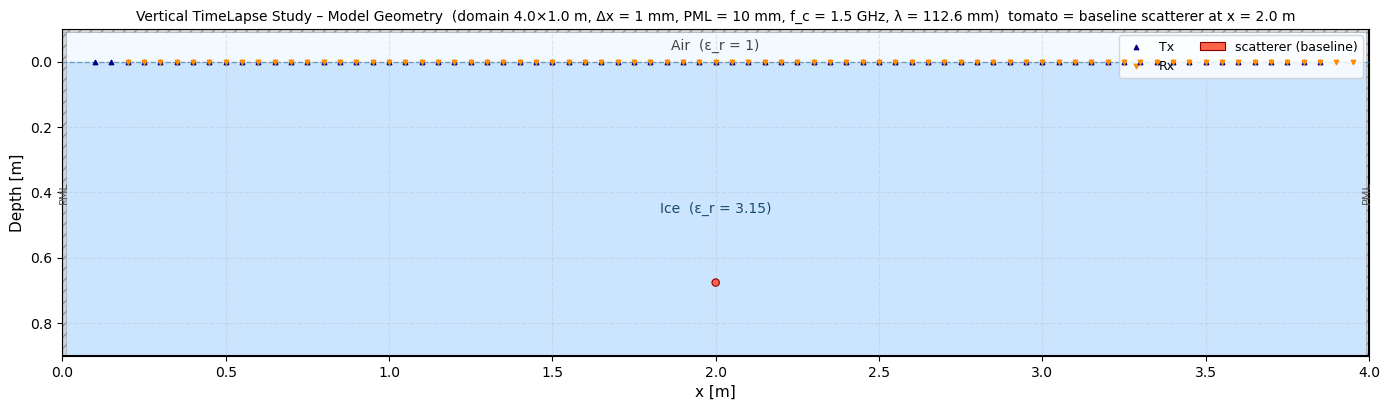

  [saved] VTL_002_Moving_scatterer__all_7_scenarios__r__28_mm_x__20_mBaseline.png


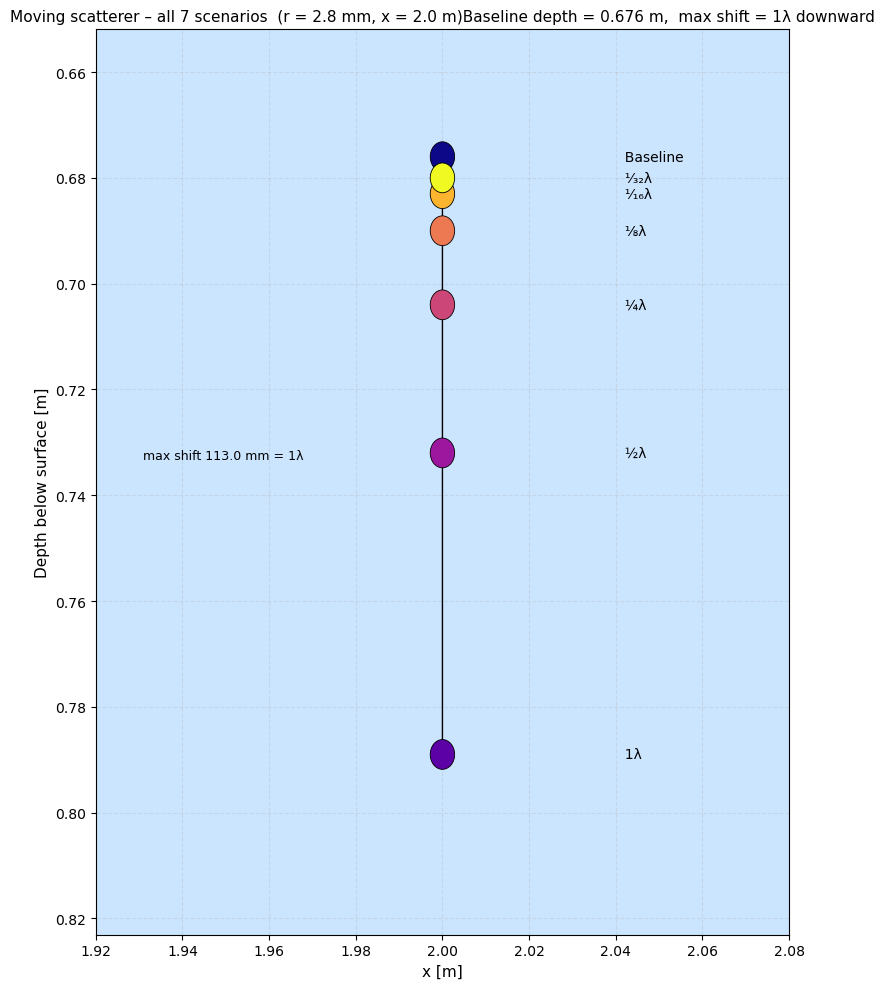

In [13]:
from matplotlib.patches import Rectangle, Circle
import matplotlib.pyplot as plt

# ── Geometry constants ────────────────────────────────────────────────────────
domain_y   = 1.0
dx_grid    = 0.001
pml_t      = 10 * dx_grid   # = 0.010 m
air_h      = domain_y - y_surface   # = 0.1 m
rx_off     = 0.1

# Depth coordinate (0 = ice surface, positive = deeper)
d_top  = -air_h           # -0.1 m
d_scat = z_scatterer      # 0.676 m  (baseline cylinder centre depth)

# All y positions and depth labels
_y_all  = [y_baseline] + y_scatterers_shift
_z_all  = [z_scatterer] + z_depths_shift
_labels = ['Baseline'] + labels
cmap_pts = plt.cm.plasma

# ── Figure 1: Full domain cross-section ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 4))

# Material regions
ax1.add_patch(Rectangle((0, 0), domain_x, y_surface,
                         facecolor='#cce5ff', edgecolor='none'))   # ice
ax1.add_patch(Rectangle((0, d_top), domain_x, air_h,
                         facecolor='#f2faff', edgecolor='none'))   # air

# PML (left, right, top)
_p = dict(facecolor='#d0d0d0', edgecolor='#888', hatch='///', alpha=0.80, lw=0.4)
ax1.add_patch(Rectangle((0,                d_top), pml_t,    domain_y, **_p))
ax1.add_patch(Rectangle((domain_x - pml_t, d_top), pml_t,    domain_y, **_p))
ax1.add_patch(Rectangle((0,                d_top), domain_x, pml_t,   **_p))

ax1.add_patch(Rectangle((0, d_top), domain_x, domain_y,
                         fill=False, edgecolor='black', lw=1.5))
ax1.axhline(0, color='steelblue', lw=1.0, ls='--', alpha=0.7)

# Tx / Rx markers (every 5th trace)
x_src_arr = 0.100 + np.arange(n_traces) * trace_step
ax1.scatter(x_src_arr[::5],           np.zeros_like(x_src_arr[::5]),
            marker='^', s=10, color='navy',       zorder=6, label='Tx')
ax1.scatter(x_src_arr[::5] + rx_off, np.zeros_like(x_src_arr[::5]),
            marker='v', s=10, color='darkorange', zorder=6, label='Rx')

# Baseline scatterer (radius x4 for visibility)
r_vis = 4 * radius_scat
ax1.add_patch(Circle((x_scatterer, d_scat), r_vis,
                      facecolor='tomato', edgecolor='#800', lw=0.8, zorder=5,
                      label='scatterer (baseline)'))

# Region text
ax1.text(domain_x/2, d_top + air_h/2, 'Air  (ε_r = 1)',
         ha='center', va='center', fontsize=10, color='#444')
ax1.text(domain_x/2, y_surface/2, f'Ice  (ε_r = {eps_r})',
         ha='center', va='center', fontsize=10, color='#1a4a6e')
ax1.text(pml_t/2,              d_top + domain_y/2, 'PML',
         ha='center', va='center', fontsize=8, color='#555', rotation=90)
ax1.text(domain_x - pml_t/2, d_top + domain_y/2, 'PML',
         ha='center', va='center', fontsize=8, color='#555', rotation=90)

ax1.set_xlim(0, domain_x)
ax1.set_ylim(y_surface, d_top)
ax1.set_xlabel('x [m]', fontsize=11)
ax1.set_ylabel('Depth [m]', fontsize=11)
ax1.set_title(
    f'Vertical TimeLapse Study – Model Geometry  '
    f'(domain {domain_x:.1f}×{domain_y:.1f} m, Δx = {dx_grid*1e3:.0f} mm, '
    f'PML = {pml_t*1e3:.0f} mm, f_c = {f_c_GHz} GHz, λ = {wavelength*1e3:.1f} mm)  '
    f'tomato = baseline scatterer at x = {x_scatterer:.1f} m',
    fontsize=10
)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(loc='upper right', fontsize=9, ncol=2)
ax1.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figure 2: Zoomed – all scatterer depths at x = 2.0 m ─────────────────────
z_min = min(_z_all); z_max = max(_z_all)
z_cen = (z_min + z_max) / 2
z_hw  = max((z_max - z_min) / 2 + 5 * radius_scat, 8 * radius_scat)
x_hw  = 0.08  # half-width of the x-window around x_scatterer [m]

fig2, ax2 = plt.subplots(figsize=(8, 10))

ax2.add_patch(Rectangle((x_scatterer - x_hw, z_cen - z_hw - 0.01),
                         2 * x_hw, 2 * z_hw + 0.04,
                         facecolor='#cce5ff', edgecolor='#aac', lw=0.5))

for i, (lbl, z_d) in enumerate(zip(_labels, _z_all)):
    col = cmap_pts(i / max(len(_labels) - 1, 1))
    ax2.add_patch(Circle((x_scatterer, z_d), radius_scat,
                          facecolor=col, edgecolor='black', lw=0.6, zorder=5))
    ax2.text(x_scatterer + x_hw * 0.5, z_d, f'  {lbl}',
             ha='left', va='center', fontsize=10)

# Arrow showing max shift
ax2.annotate('', xy=(x_scatterer, _z_all[1]),
             xytext=(x_scatterer, _z_all[0]),
             arrowprops=dict(arrowstyle='->', color='k', lw=1.0))
ax2.text(x_scatterer - x_hw * 0.4, (_z_all[0] + _z_all[1]) / 2, f'max shift {(_z_all[1]-_z_all[0])*1e3:.1f} mm = 1λ', ha='right', va='center', fontsize=9)

ax2.set_xlim(x_scatterer - x_hw, x_scatterer + x_hw)
ax2.set_ylim(z_cen + z_hw + 0.02, z_cen - z_hw - 0.01)
ax2.set_xlabel('x [m]', fontsize=11)
ax2.set_ylabel('Depth below surface [m]', fontsize=11)
ax2.set_title(
    f'Moving scatterer – all 7 scenarios  ' f'(r = {radius_scat*1e3:.1f} mm, x = {x_scatterer:.1f} m)'
    f'Baseline depth = {z_scatterer:.3f} m,  max shift = 1λ downward',
    fontsize=11
)
ax2.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary.

In [14]:
# Uncomment and run to execute gprMax simulations for each scenario.
# Each scenario requires n_traces = 380 model runs.

# from gprMax.gprMax import api
# api(r'vertical_timelapse_study/background/background.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/baseline/baseline.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_1lambda/shift_1lambda.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_0p5lambda/shift_0p5lambda.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_0p25lambda/shift_0p25lambda.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_0p125lambda/shift_0p125lambda.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_0p0625lambda/shift_0p0625lambda.in', n=380, geometry_fixed=True)
# api(r'vertical_timelapse_study/shift_0p03125lambda/shift_0p03125lambda.in', n=380, geometry_fixed=True)


In [15]:
# Uncomment and run to merge per-trace .out files into a single merged .out file.

# from tools.outputfiles_merge import merge_files
# merge_files(r'vertical_timelapse_study/background/background', True)
# merge_files(r'vertical_timelapse_study/baseline/baseline', True)
# merge_files(r'vertical_timelapse_study/shift_1lambda/shift_1lambda', True)
# merge_files(r'vertical_timelapse_study/shift_0p5lambda/shift_0p5lambda', True)
# merge_files(r'vertical_timelapse_study/shift_0p25lambda/shift_0p25lambda', True)
# merge_files(r'vertical_timelapse_study/shift_0p125lambda/shift_0p125lambda', True)
# merge_files(r'vertical_timelapse_study/shift_0p0625lambda/shift_0p0625lambda', True)
# merge_files(r'vertical_timelapse_study/shift_0p03125lambda/shift_0p03125lambda', True)


# Loading in the data and removing direct wave

In [16]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'vertical_timelapse_study/background/background_merged.out', rxnumber, rxcomponent
)

_paths = [
    'vertical_timelapse_study/baseline/baseline_merged.out',
    'vertical_timelapse_study/shift_1lambda/shift_1lambda_merged.out',
    'vertical_timelapse_study/shift_0p5lambda/shift_0p5lambda_merged.out',
    'vertical_timelapse_study/shift_0p25lambda/shift_0p25lambda_merged.out',
    'vertical_timelapse_study/shift_0p125lambda/shift_0p125lambda_merged.out',
    'vertical_timelapse_study/shift_0p0625lambda/shift_0p0625lambda_merged.out',
    'vertical_timelapse_study/shift_0p03125lambda/shift_0p03125lambda_merged.out',
]
raw_outputs    = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs_static = [r - output_background for r in raw_outputs]   # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs_static[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

data_pre    = [('Background', output_background)] + list(zip(labels_all, raw_outputs))
data_static = list(zip(labels_all, outputs_static))

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs_static[0].shape}')

# Expected apex arrival times for each scenario (2 * depth / v_ice)
t_apex = [2 * z / v_ice for z in [z_scatterer] + z_depths_shift]
print('\nExpected apex arrival times:')
for lbl, t in zip(labels_all, t_apex):
    print(f'  {lbl:>8}: {t:.3f} ns')


dt = 0.002359 ns,  n_t = 8481,  t_max = 20.00 ns
Data shape (n_t × n_tr): (8481, 380)

Expected apex arrival times:
  Baseline: 8.004 ns
        1λ: 9.342 ns
        ½λ: 8.667 ns
        ¼λ: 8.336 ns
        ⅛λ: 8.170 ns
     ¹⁄₁₆λ: 8.087 ns
     ¹⁄₃₂λ: 8.051 ns


# Visualisation

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11756\3818680691.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [saved] VTL_003_GPR_B-Scans__Background_Baseline_and_Vertical_TimeLapsed_Mod.png


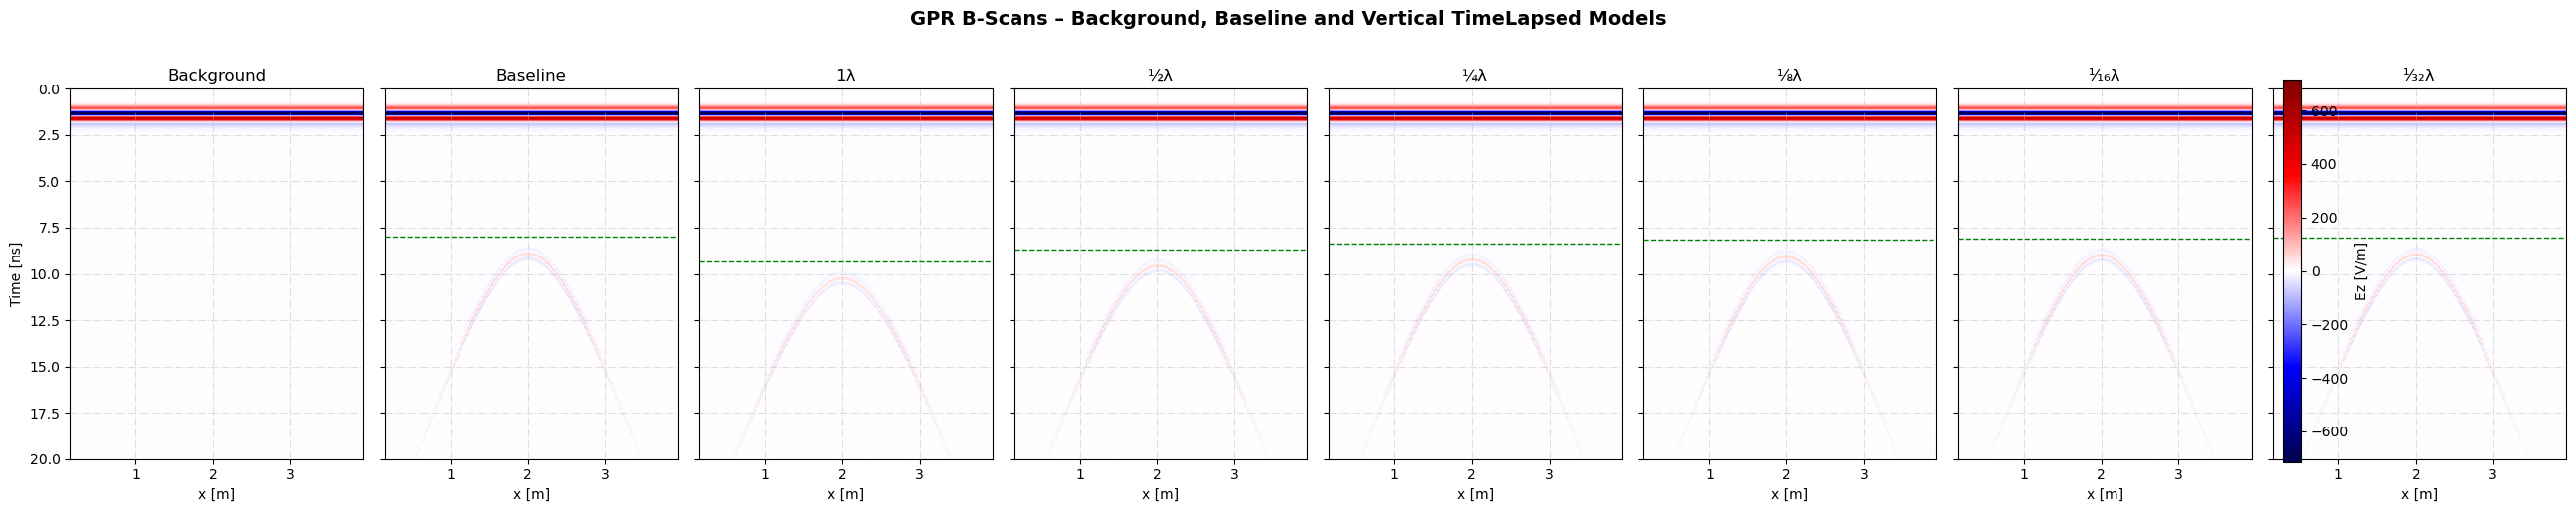

In [17]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

fig, axes = plt.subplots(1, 8, figsize=(26, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_pre)

for i, (ax, (title, d)) in enumerate(zip(axes, data_pre)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x [m]', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=10)
    ax.grid(linestyle='-.', alpha=0.4)
    if i > 0:  # mark expected apex time for each scenario (all at x = 2.0)
        ax.axhline(t_apex[i - 1], color='green', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans – Background, Baseline and Vertical TimeLapsed Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11756\2283819278.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [saved] VTL_004_GPR_B-Scans__Background_Subtracted__green_dashed__expected_a.png


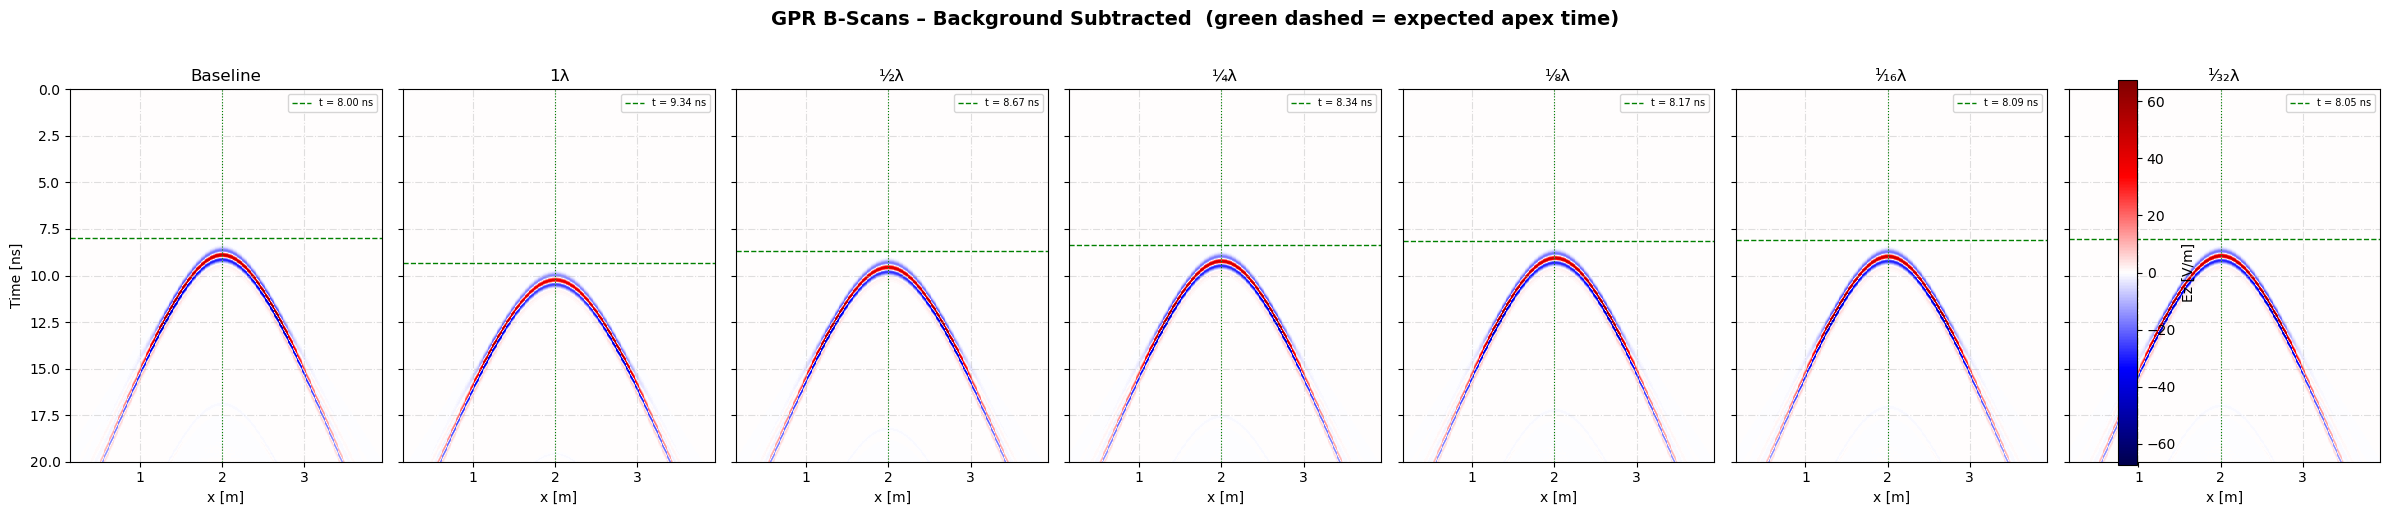

In [18]:
fig, axes = plt.subplots(1, 7, figsize=(24, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_static)

for i, (ax, (title, d)) in enumerate(zip(axes, data_static)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x [m]', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=10)
    ax.grid(linestyle='-.', alpha=0.4)
    ax.axhline(t_apex[i], color='green', linestyle='--', linewidth=1,
               label=f't = {t_apex[i]:.2f} ns')
    ax.axvline(x_scatterer, color='green', linestyle=':', linewidth=0.8)
    ax.legend(fontsize=7, loc='upper right')

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans – Background Subtracted  (green dashed = expected apex time)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.

## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|---|---|
| End taper (half-cosine) | Suppress ringing from late-time hyperbola tails |
| Exponential decay taper | Down-weight late, noisy arrivals |
| t0 roll | Compensate for Ricker wavelet peak delay so zero-offset apex aligns with t=0 |

In [19]:
import sys, pathlib
_here = pathlib.Path.cwd()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))
from helper_functions.migration import PylopsKirchoffMigration, gazdag_migration, write_backprop_files


  [saved] VTL_005_Effect_of_Tapering_and_t0_Shift__1λ_dataset_single_trace.png


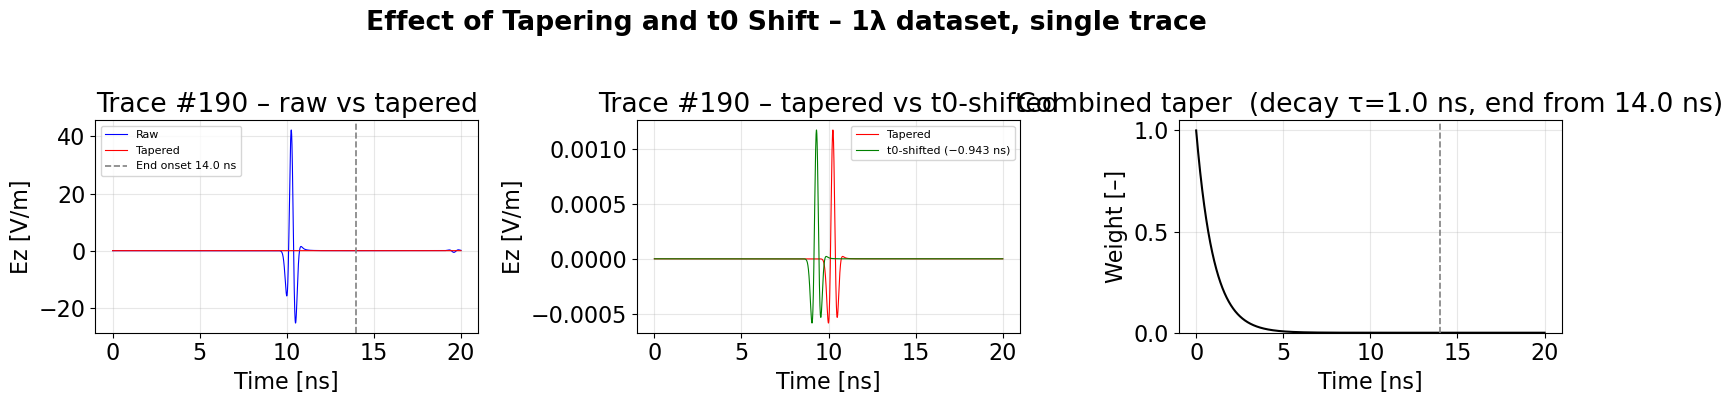

  [saved] VTL_006_B-scan_effect_of_tapering_and_t0_shift__1λ_dataset.png


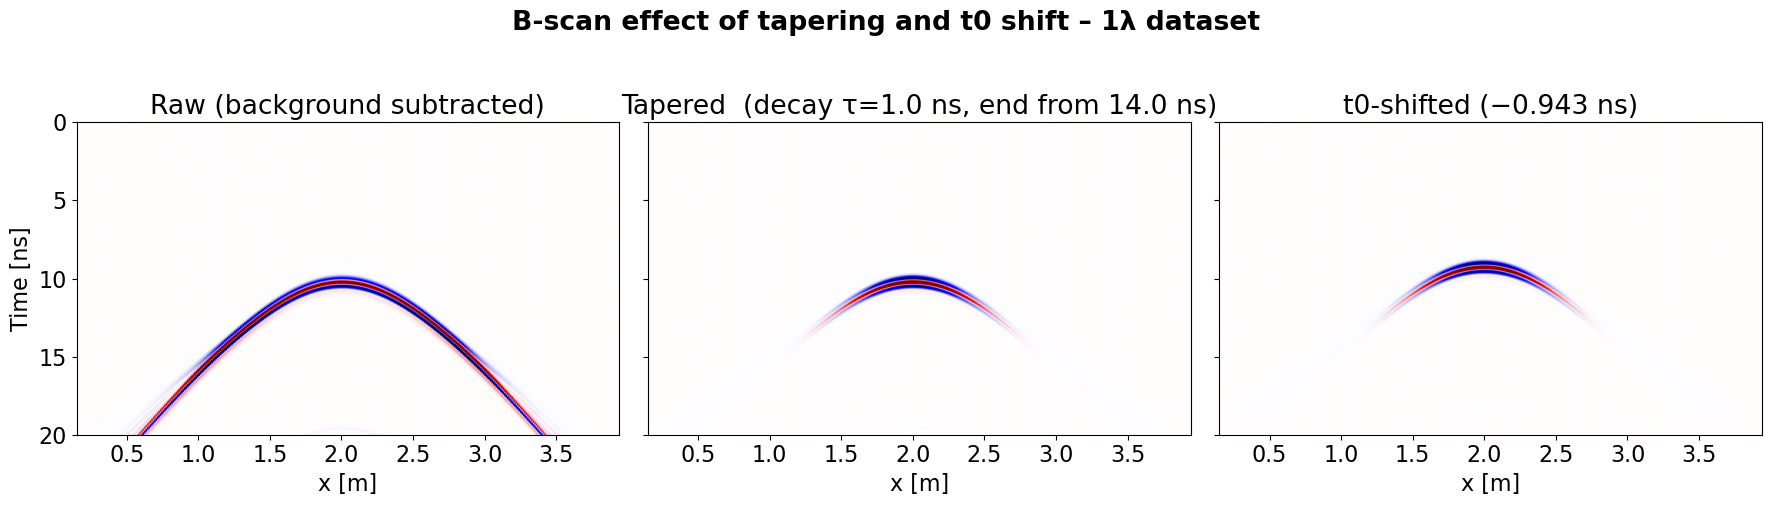

In [20]:
# ── Taper & t0-shift parameters ────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]
taper_decay_ns = 1.0    # exponential decay time constant [ns]
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ───────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    bscan   = data_nt_ntr.T.copy()
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the 1λ dataset ────────────────────────────────────
_demo = outputs_static[1]    # (n_t, n_tr) - 1λ background-subtracted
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(time_ns, _demo[:, mid_tr], 'b', lw=0.8, label='Raw')
axes[0].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[0].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End onset {taper_end_ns} ns')
axes[0].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} – raw vs tapered')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[1].plot(time_ns, _shifted[mid_tr], 'g', lw=0.8, label=f't0-shifted (−{t0_ns:.3f} ns)')
axes[1].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} – tapered vs t0-shifted')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(time_ns, taper_combined, 'k', lw=1.5)
axes[2].axvline(taper_end_ns, color='gray', ls='--', lw=1.2)
axes[2].set(xlabel='Time [ns]', ylabel='Weight [–]',
            title=f'Combined taper  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)',
            ylim=(0, 1.05))
axes[2].grid(alpha=0.3)

plt.suptitle('Effect of Tapering and t0 Shift – 1λ dataset, single trace',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
kw = dict(aspect='auto', cmap='seismic', extent=extent_bscan, origin='upper')

vmax0 = np.max(np.abs(_demo)) * 0.5
axes[0].imshow(_demo, **kw, vmin=-vmax0, vmax=vmax0)
axes[0].set(title='Raw (background subtracted)', xlabel='x [m]', ylabel='Time [ns]')

vmax1 = np.max(np.abs(_tapered)) * 0.5
axes[1].imshow(_tapered.T, **kw, vmin=-vmax1, vmax=vmax1)
axes[1].set(title=f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', xlabel='x [m]')

vmax2 = np.max(np.abs(_shifted)) * 0.5
axes[2].imshow(_shifted.T, **kw, vmin=-vmax2, vmax=vmax2)
axes[2].set(title=f't0-shifted (−{t0_ns:.3f} ns)', xlabel='x [m]')

plt.suptitle('B-scan effect of tapering and t0 shift – 1λ dataset', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [21]:
# ── Kirchhoff migration on all 7 datasets ─────────────────────────────────
migrated = {}
z_depths_all = [z_scatterer] + z_depths_shift   # depth of scatterer per scenario

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img


[Baseline] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.9 s  shape=(180, 380)
[1λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.9 s  shape=(180, 380)
[½λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
3.0 s  shape=(180, 380)
[¼λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.9 s  shape=(180, 380)
[⅛λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.5 s  shape=(180, 380)
[¹⁄₁₆λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.5 s  shape=(180, 380)
[¹⁄₃₂λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 68400)
2.5 s  shape=(180, 380)


  [saved] VTL_007_Kirchhoff_Migration__All_7_Datasets____f_c15_GHz____aperture.png


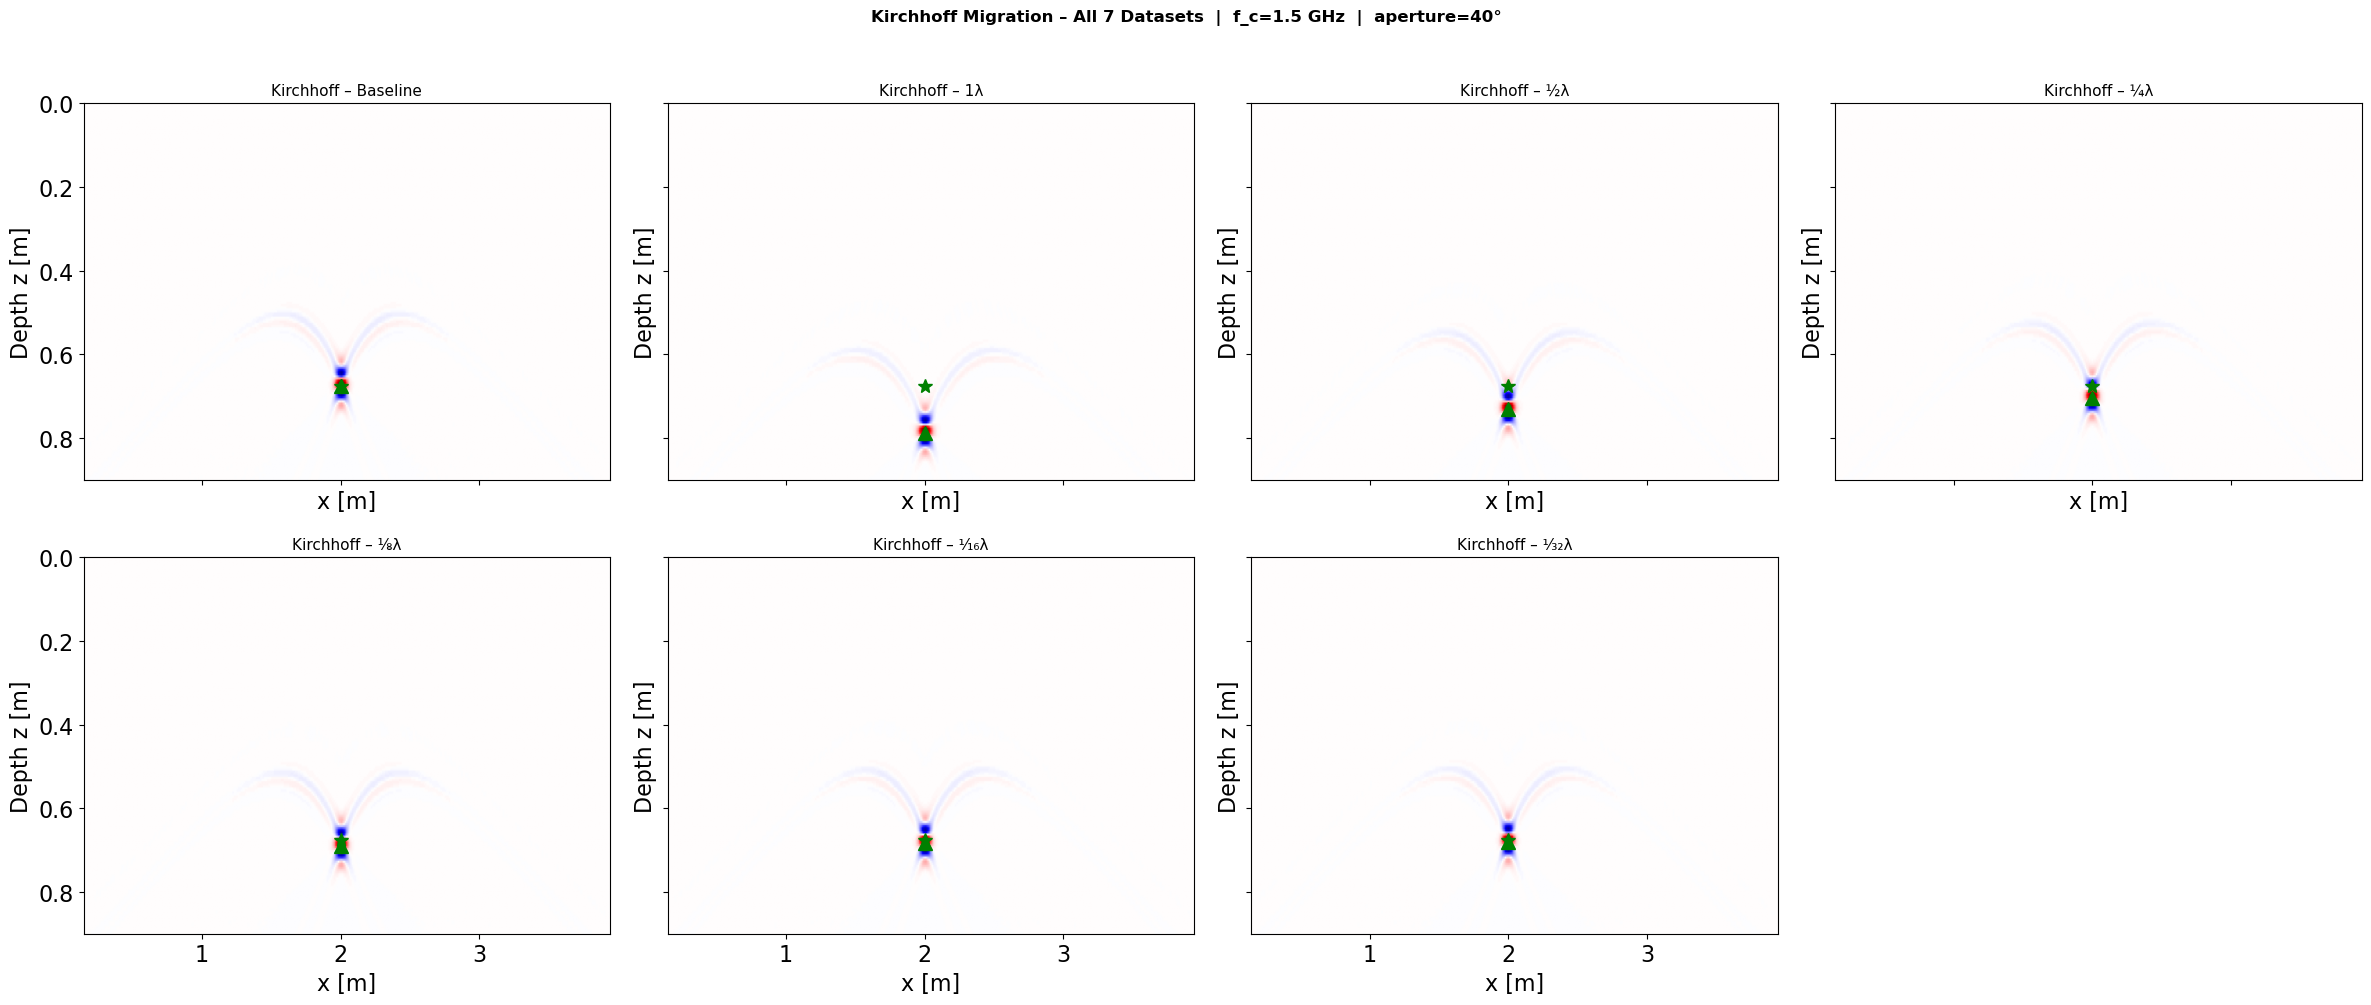

  [saved] VTL_008_Kirchhoff_Migration_zoomed____f_c15_GHz____aperture40.png


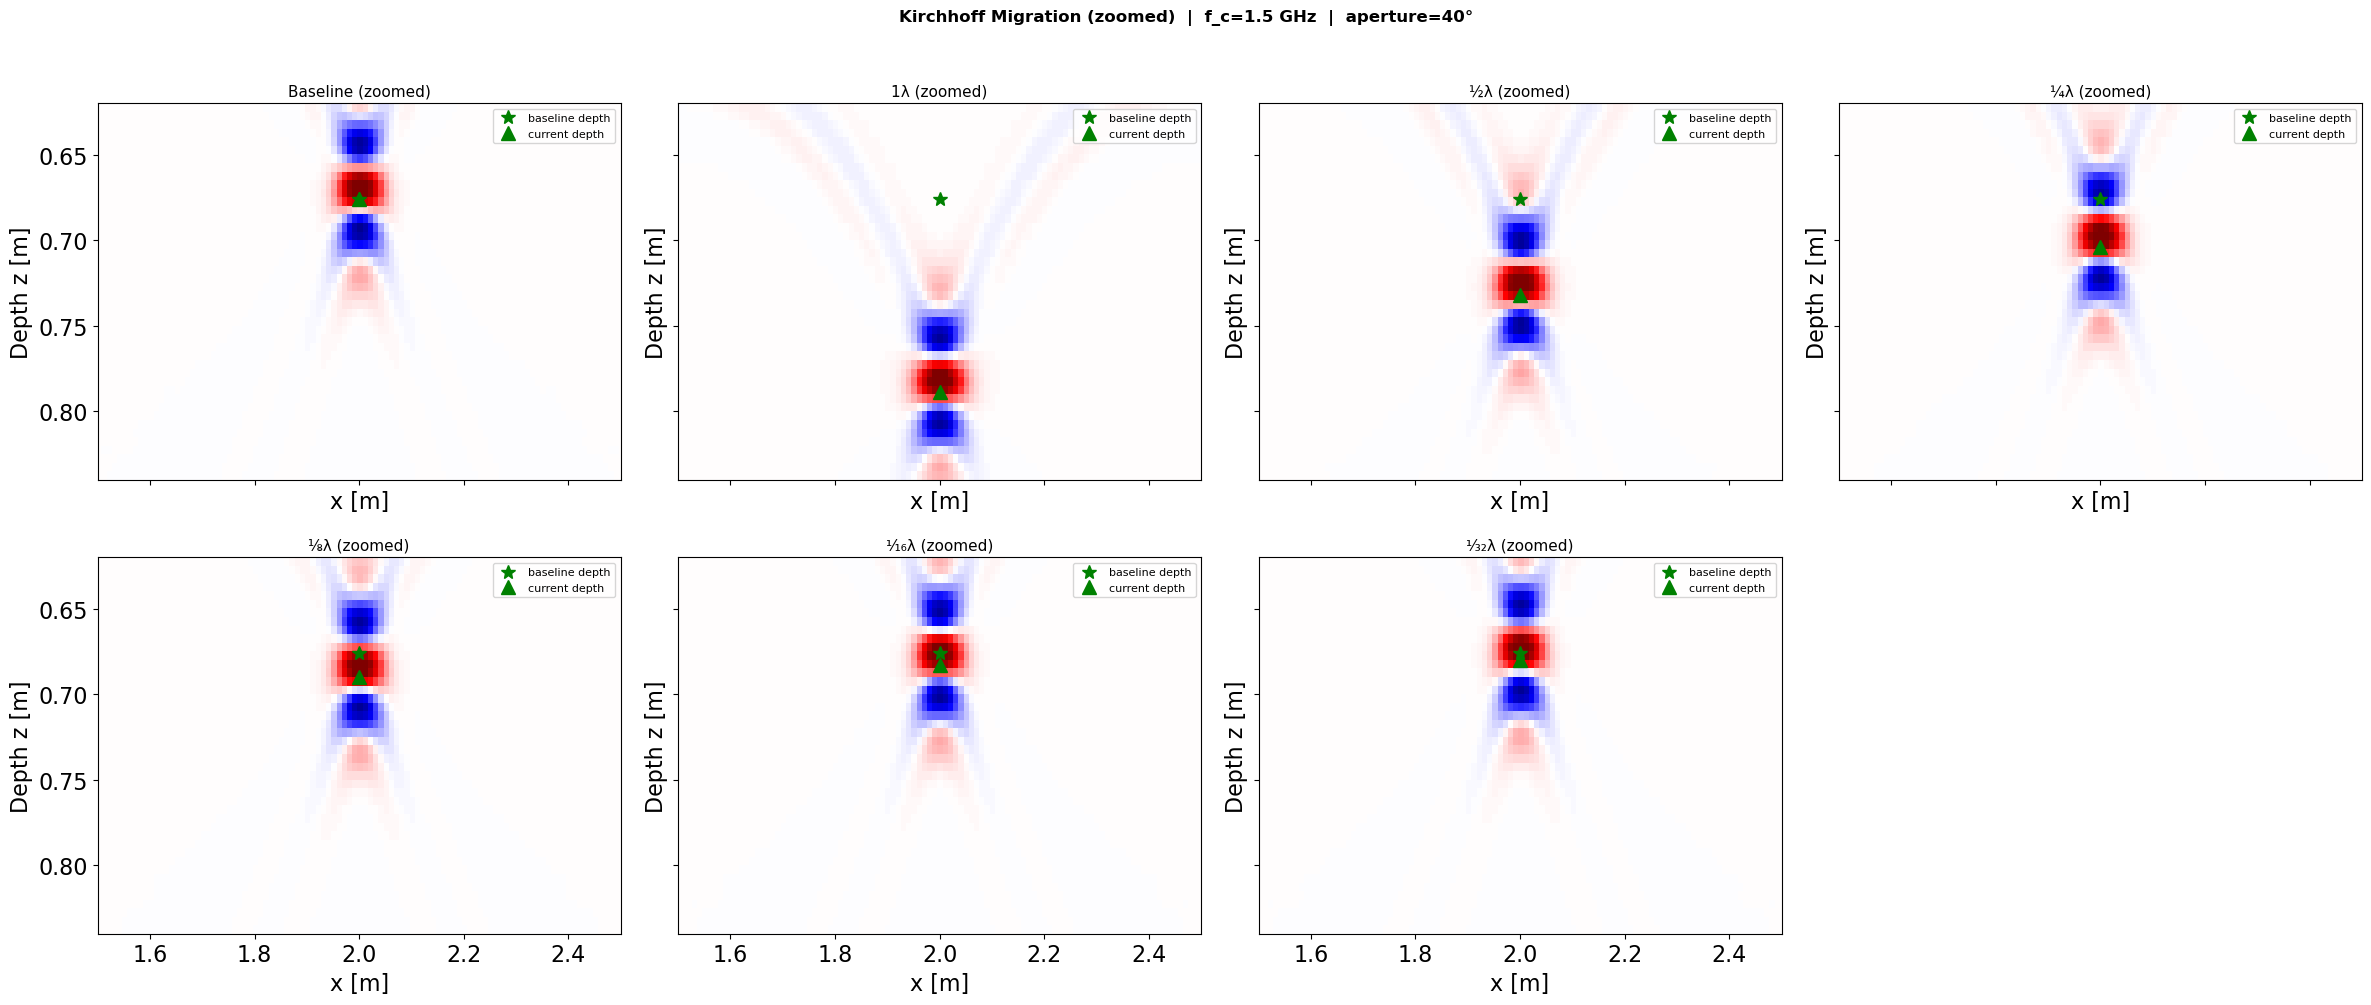

In [22]:
# ── Plot: full extent ──────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0], 'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i], 'g^', ms=10, zorder=5, label='current depth')
    ax.set_title(f'Kirchhoff – {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Kirchhoff Migration – All 7 Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0], 'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i], 'g^', ms=10, zorder=5, label='current depth')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.84, 0.62)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


  [saved] VTL_009_Kirchhoff_Migration__TimeLapse_Differences_migrated__migrate.png


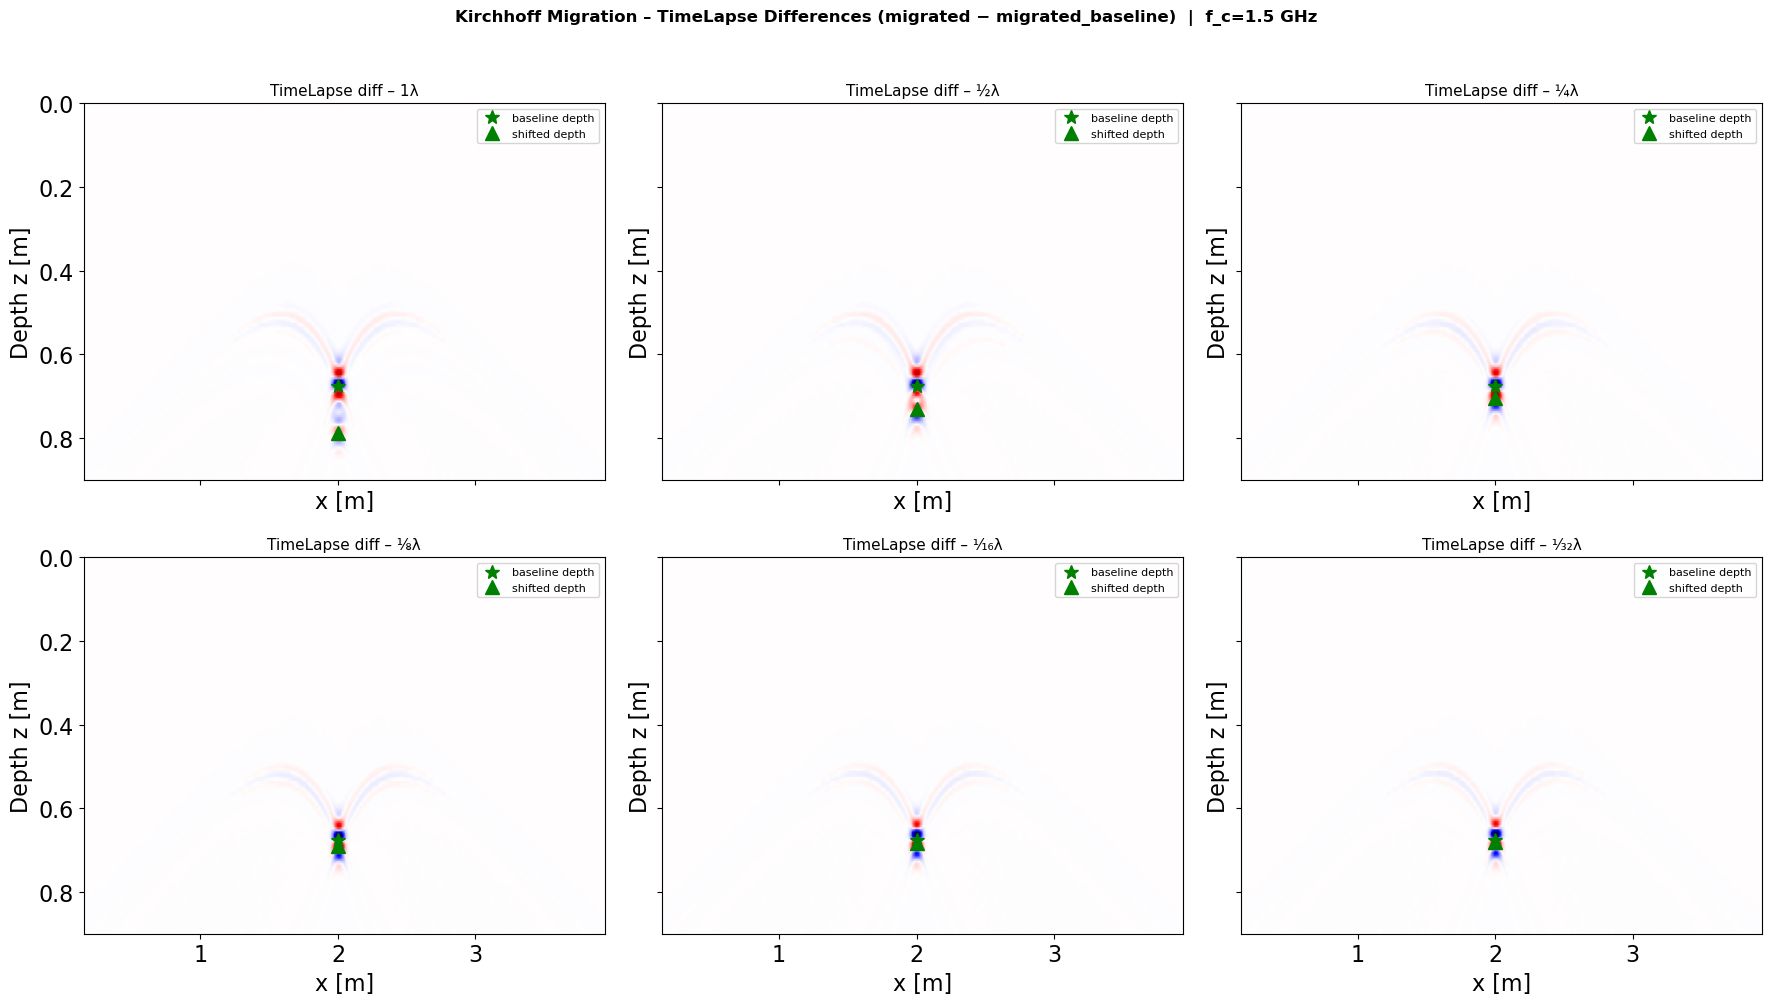

  [saved] VTL_010_Kirchhoff_Migration__TimeLapse_Differences_zoomed.png


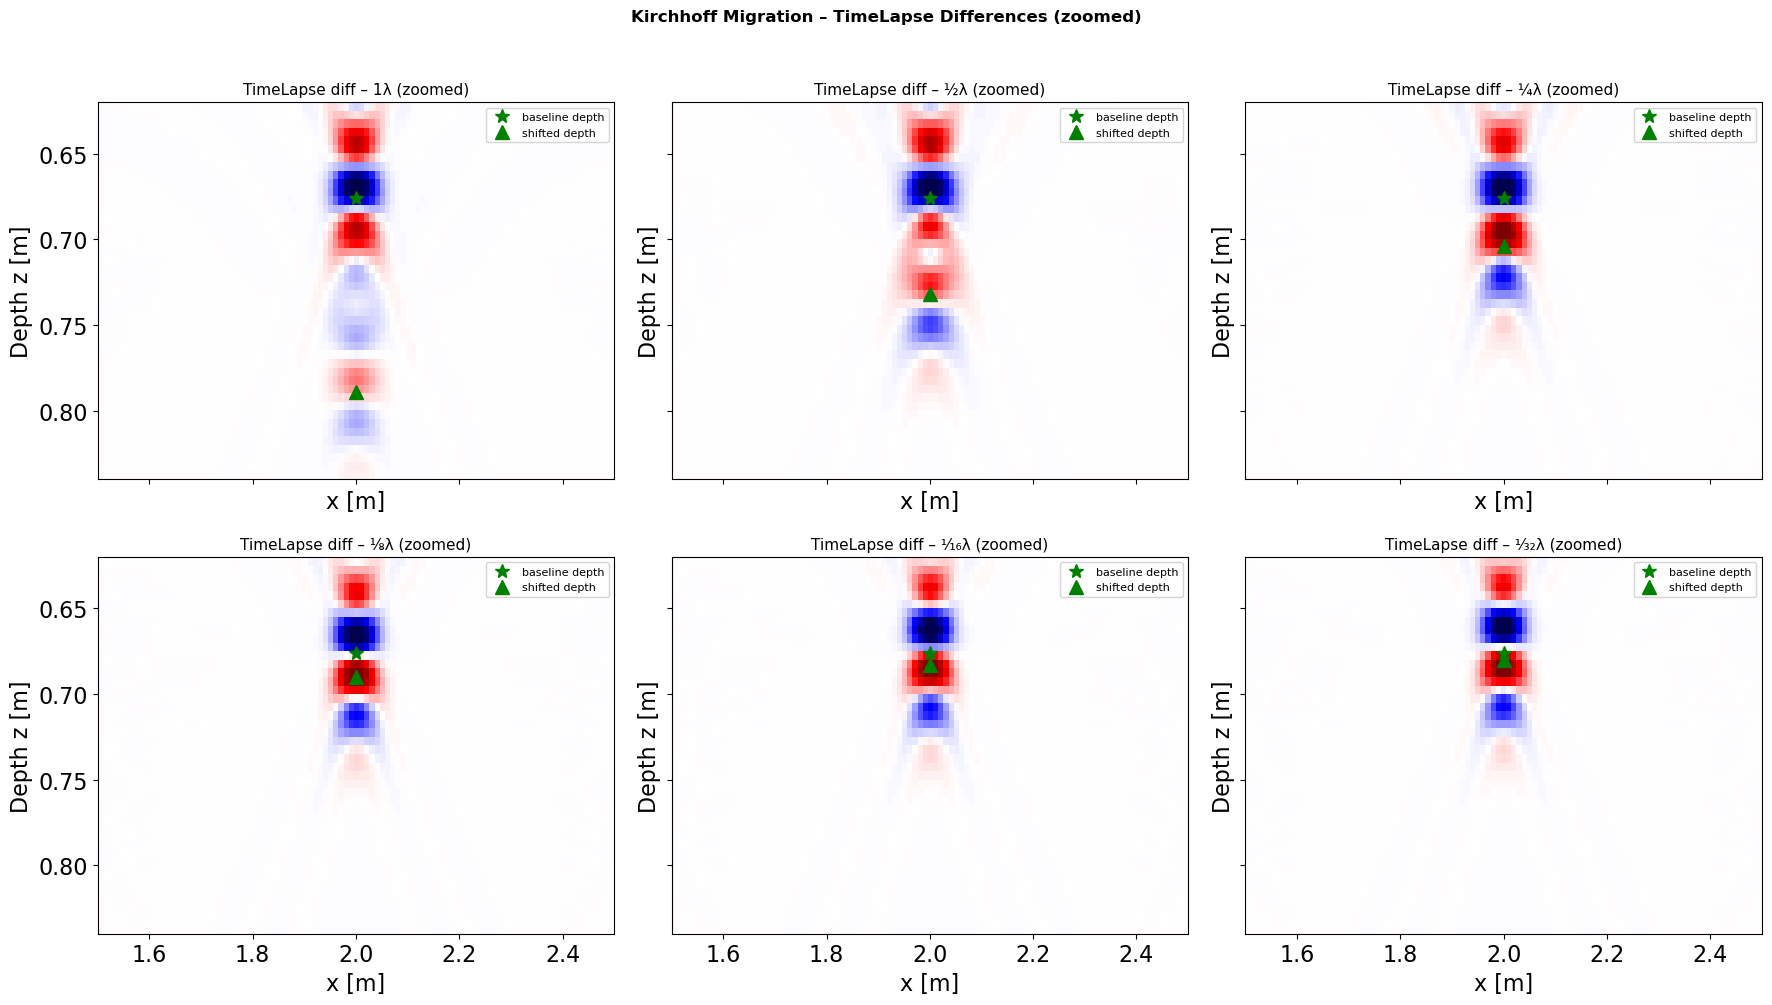

In [23]:
# ── Kirchhoff timelapse differences (migrated − migrated_baseline) ─────────
migrated_diff = {label: migrated[label] - migrated['Baseline'] for label in labels}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0],     'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i + 1], 'g^', ms=10, zorder=5, label='shifted depth')
    ax.set_title(f'TimeLapse diff – {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration – TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_timelapse_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0],     'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i + 1], 'g^', ms=10, zorder=5, label='shifted depth')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.84, 0.62)
    ax.set_title(f'TimeLapse diff – {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Kirchhoff Migration – TimeLapse Differences (zoomed)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_timelapse_diff_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.

In [24]:
import pylops

## Run Migration on All Datasets

In [25]:
# ── Gazdag phase-shift migration on all 7 datasets ─────────────────────────
migrated_gz = {}

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) – time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img


[Baseline] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 172.5 s  shape=(180, 380)
[1λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 170.4 s  shape=(180, 380)
[½λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 171.3 s  shape=(180, 380)
[¼λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 171.7 s  shape=(180, 380)
[⅛λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 175.1 s  shape=(180, 380)
[¹⁄₁₆λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 176.5 s  shape=(180, 380)
[¹⁄₃₂λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 181.9 s  shape=(180, 380)


  [saved] VTL_011_Gazdag_Phase-Shift_Migration__All_7_Datasets____f_c15_GHz.png


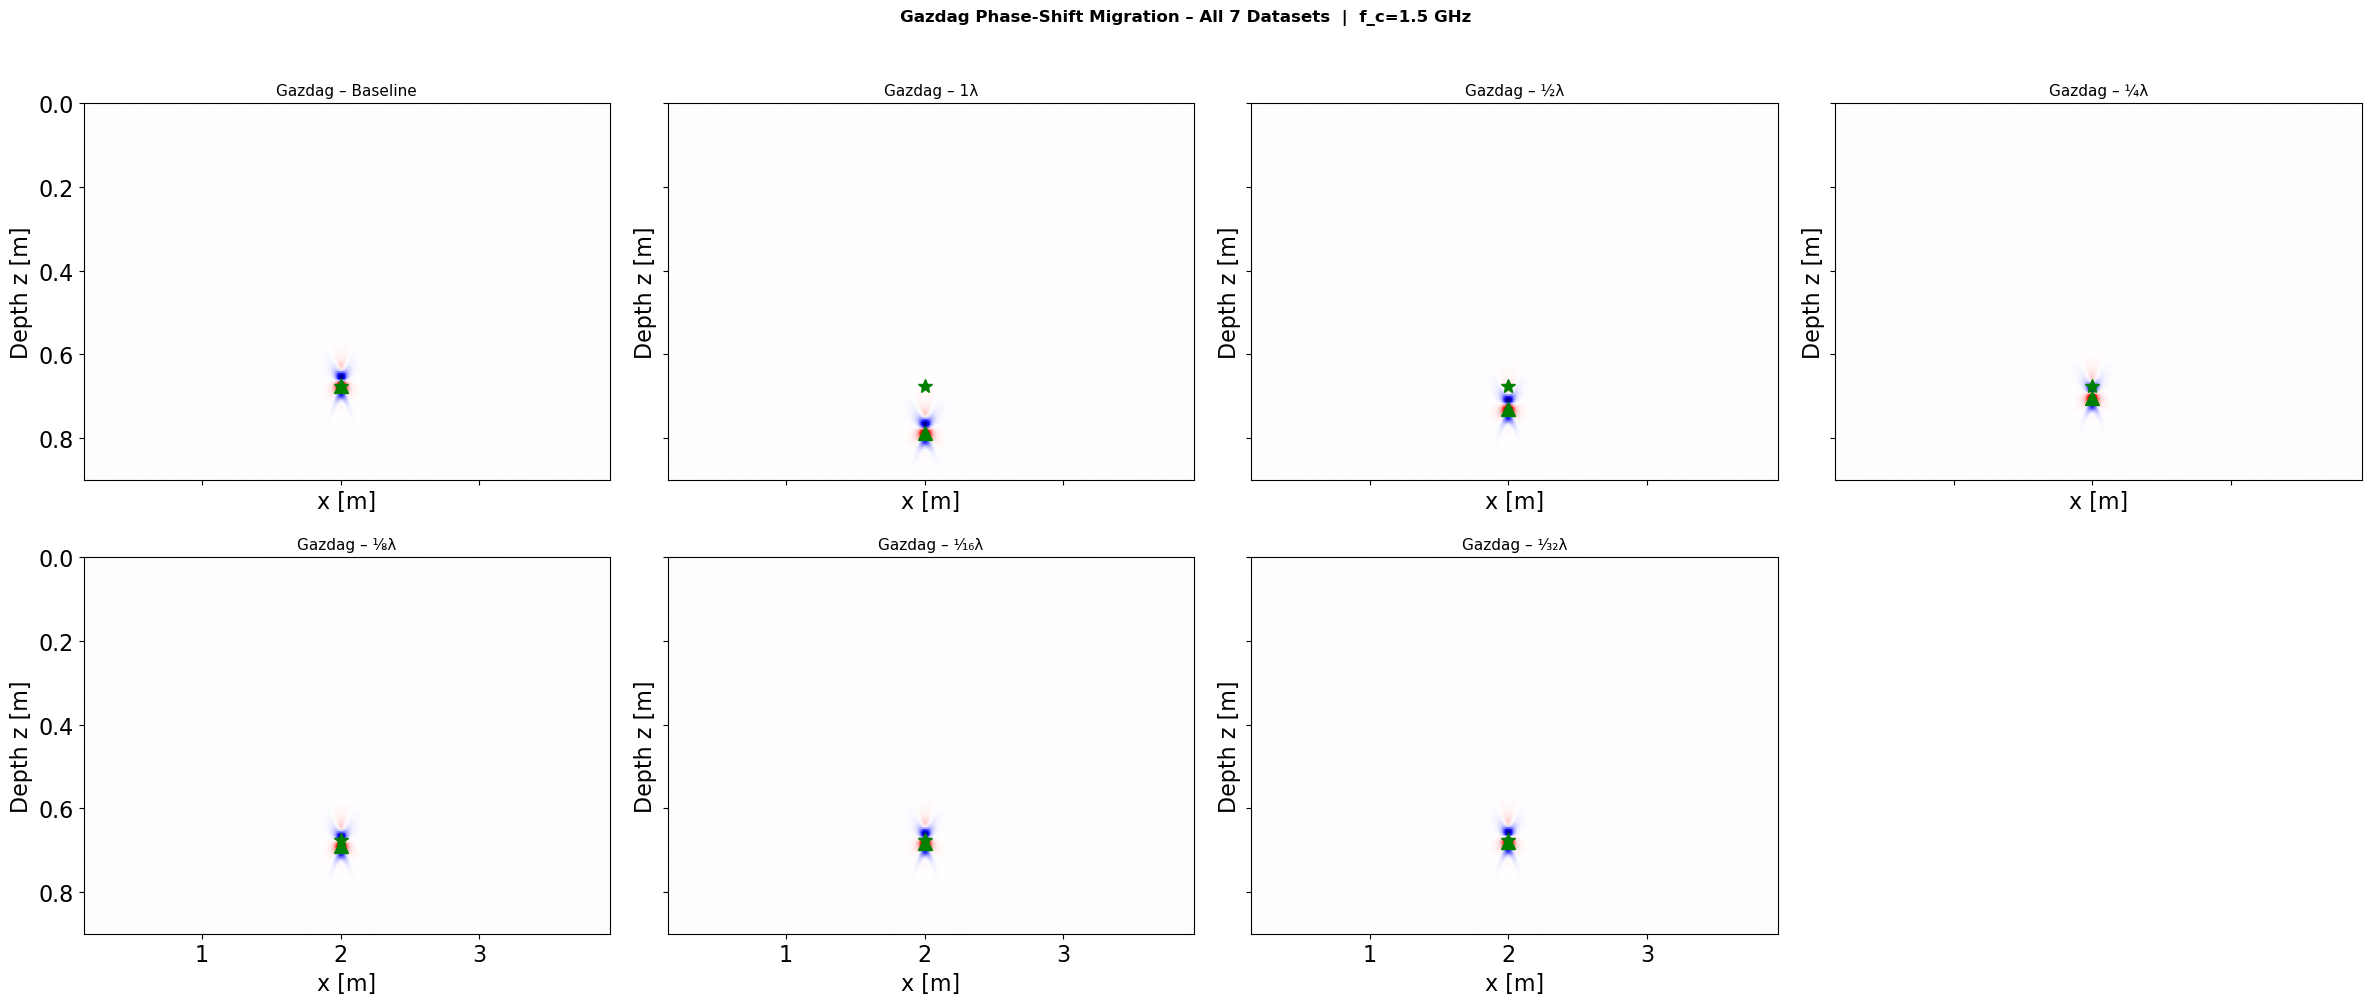

  [saved] VTL_012_Gazdag_Phase-Shift_Migration_zoomed____f_cf_c_GHz_GHz.png


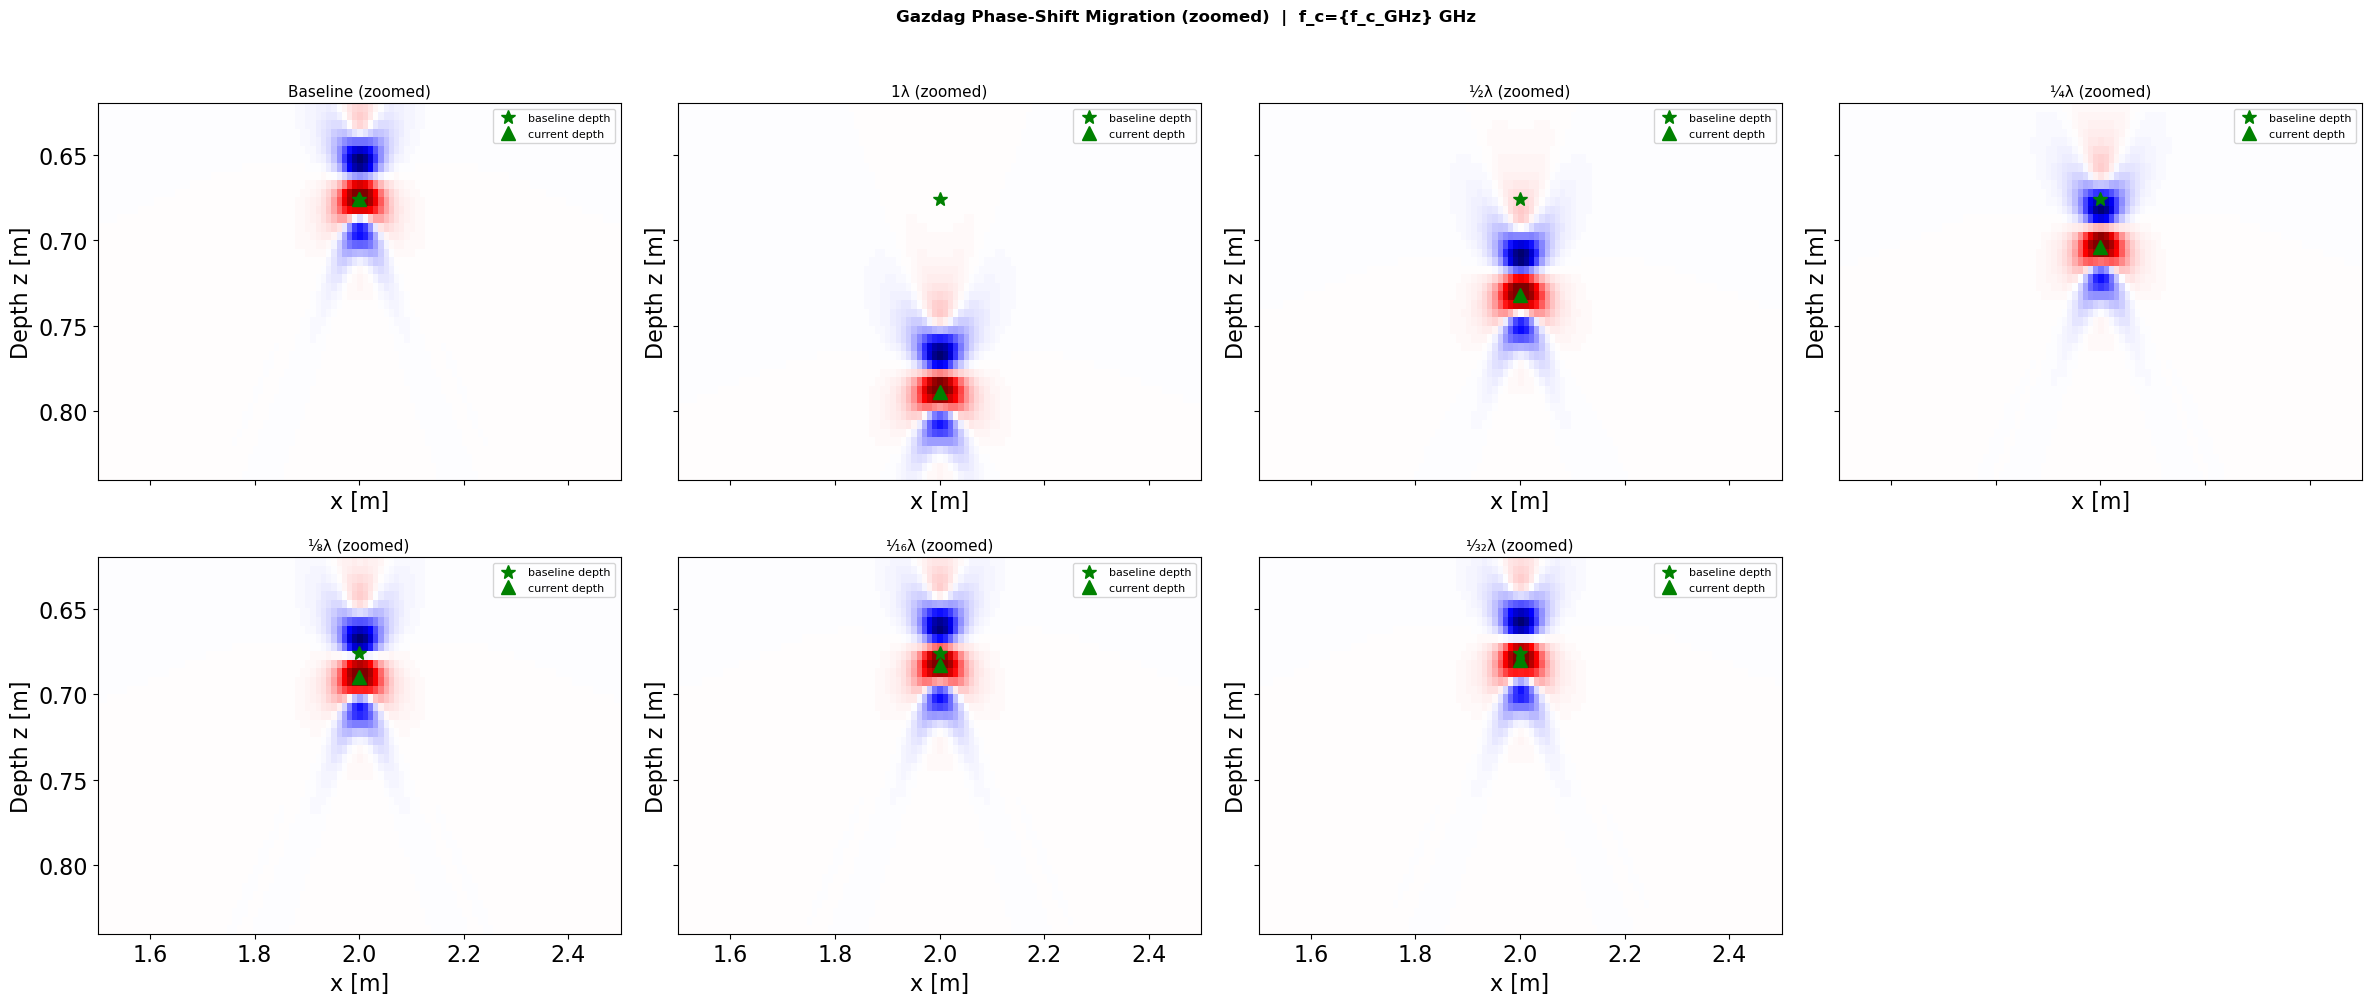

In [26]:
# ── Plot: full extent ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0], 'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i], 'g^', ms=10, zorder=5, label='current depth')
    ax.set_title(f'Gazdag – {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Gazdag Phase-Shift Migration – All 7 Datasets  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0], 'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i], 'g^', ms=10, zorder=5, label='current depth')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.84, 0.62)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


  [saved] VTL_013_Gazdag_Migration__TimeLapse_Differences_migrated__migrated_b.png


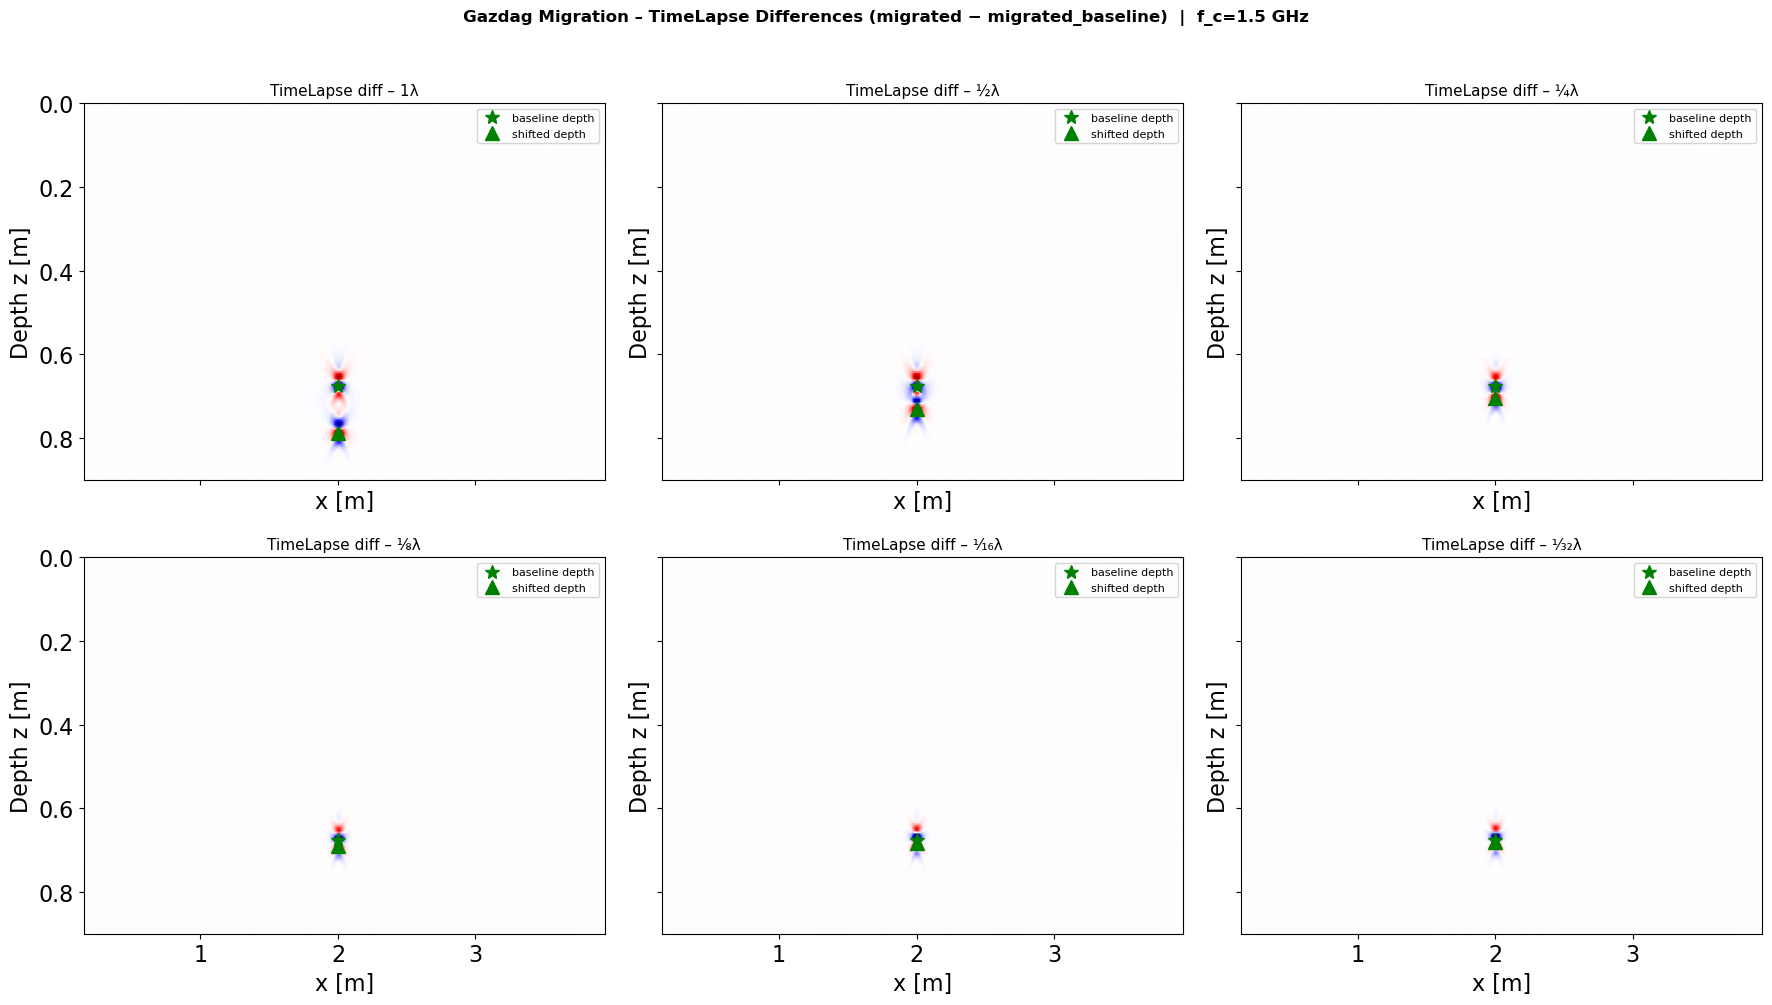

  [saved] VTL_014_Gazdag_Migration__TimeLapse_Differences_zoomed.png


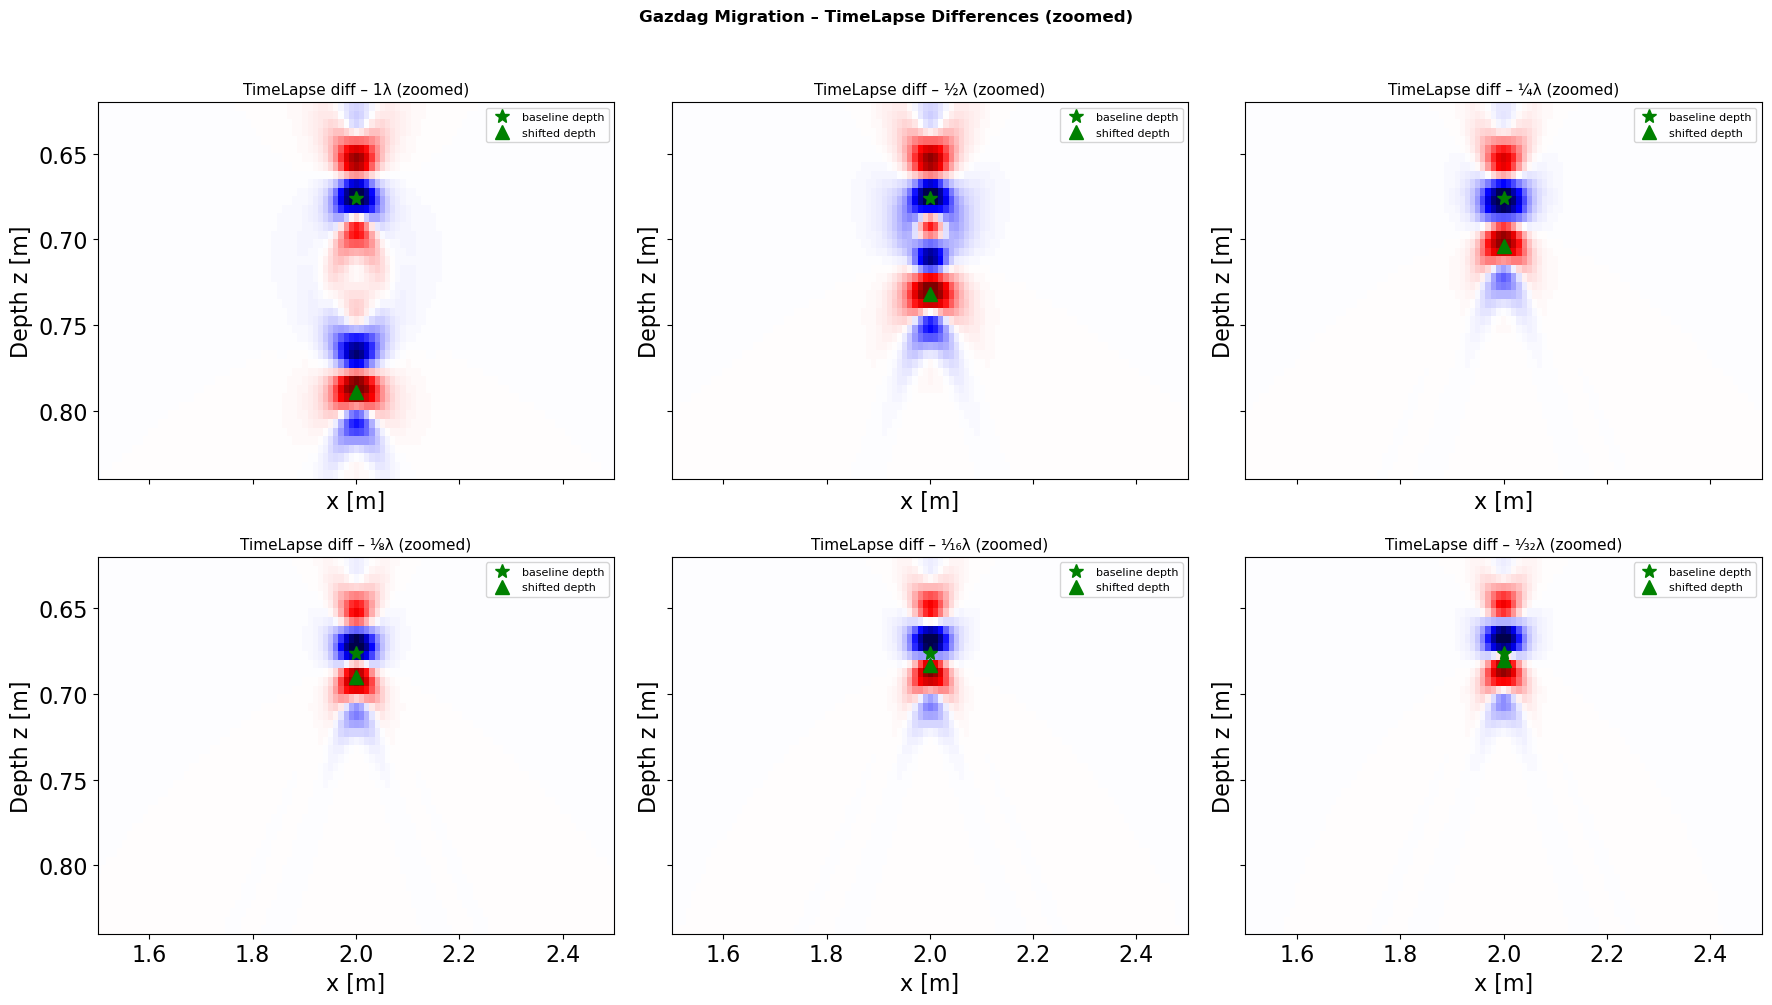

In [27]:
# ── Gazdag timelapse differences ──────────────────────────────────────────
migrated_gz_diff = {label: migrated_gz[label] - migrated_gz['Baseline'] for label in labels}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0],     'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i + 1], 'g^', ms=10, zorder=5, label='shifted depth')
    ax.set_title(f'TimeLapse diff – {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Migration – TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer, z_depths_all[0],     'g*', ms=10, zorder=5, label='baseline depth')
    ax.plot(x_scatterer, z_depths_all[i + 1], 'g^', ms=10, zorder=5, label='shifted depth')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.84, 0.62)
    ax.set_title(f'TimeLapse diff – {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Gazdag Migration – TimeLapse Differences (zoomed)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan as sources at the receiver positions and let gprMax propagate the wavefield backward in time.

In [28]:
# ── Back-propagation parameters ───────────────────────────────────────────
slugs_all = ['baseline', '1lambda', '0p5lambda', '0p25lambda', '0p125lambda', '0p0625lambda', '0p03125lambda']
STRIDE   = 1    # use every Nth trace
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time

# ── Generate files for all 7 datasets ────────────────────────────────────
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)\n')
bp_paths = {}
for label, slug, raw in zip(labels_all, slugs_all, outputs_static):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        STUDY_ROOT, label, slug, tapered, dt_ns, x_traces,
        t0_ns, eps_r, v_ice, stride=STRIDE, n_snap=N_SNAP, snap_win=SNAP_WIN
    )
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB')
    print(f'           {in_path}')


Back-propagation file generation  (stride=1, 30 snapshots)

  [Baseline]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.4 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\backprop\baseline\backprop_baseline.in
  [1λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.3 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\backprop\1lambda\backprop_1lambda.in
  [½λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.4 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\backprop\0p5lambda\backprop_0p5lambda.in
  [¼λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.4 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\backprop\0p25lambda\backprop_0p25lambda.in
  [⅛λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.4 MB

[Baseline]  29 snaps  |  focus idx=19  t=19.316 ns
[1λ]  29 snaps  |  focus idx=19  t=19.316 ns
[½λ] No snapshots in backprop_0p5lambda_snaps – skipping
[¼λ] No snapshots in backprop_0p25lambda_snaps – skipping
[⅛λ] No snapshots in backprop_0p125lambda_snaps – skipping
[¹⁄₁₆λ]  29 snaps  |  focus idx=19  t=19.316 ns
[¹⁄₃₂λ]  29 snaps  |  focus idx=19  t=19.316 ns
  [saved] VTL_015_Back-Propagation_E__All_7_Datasets____focus_at_1906_ns.png


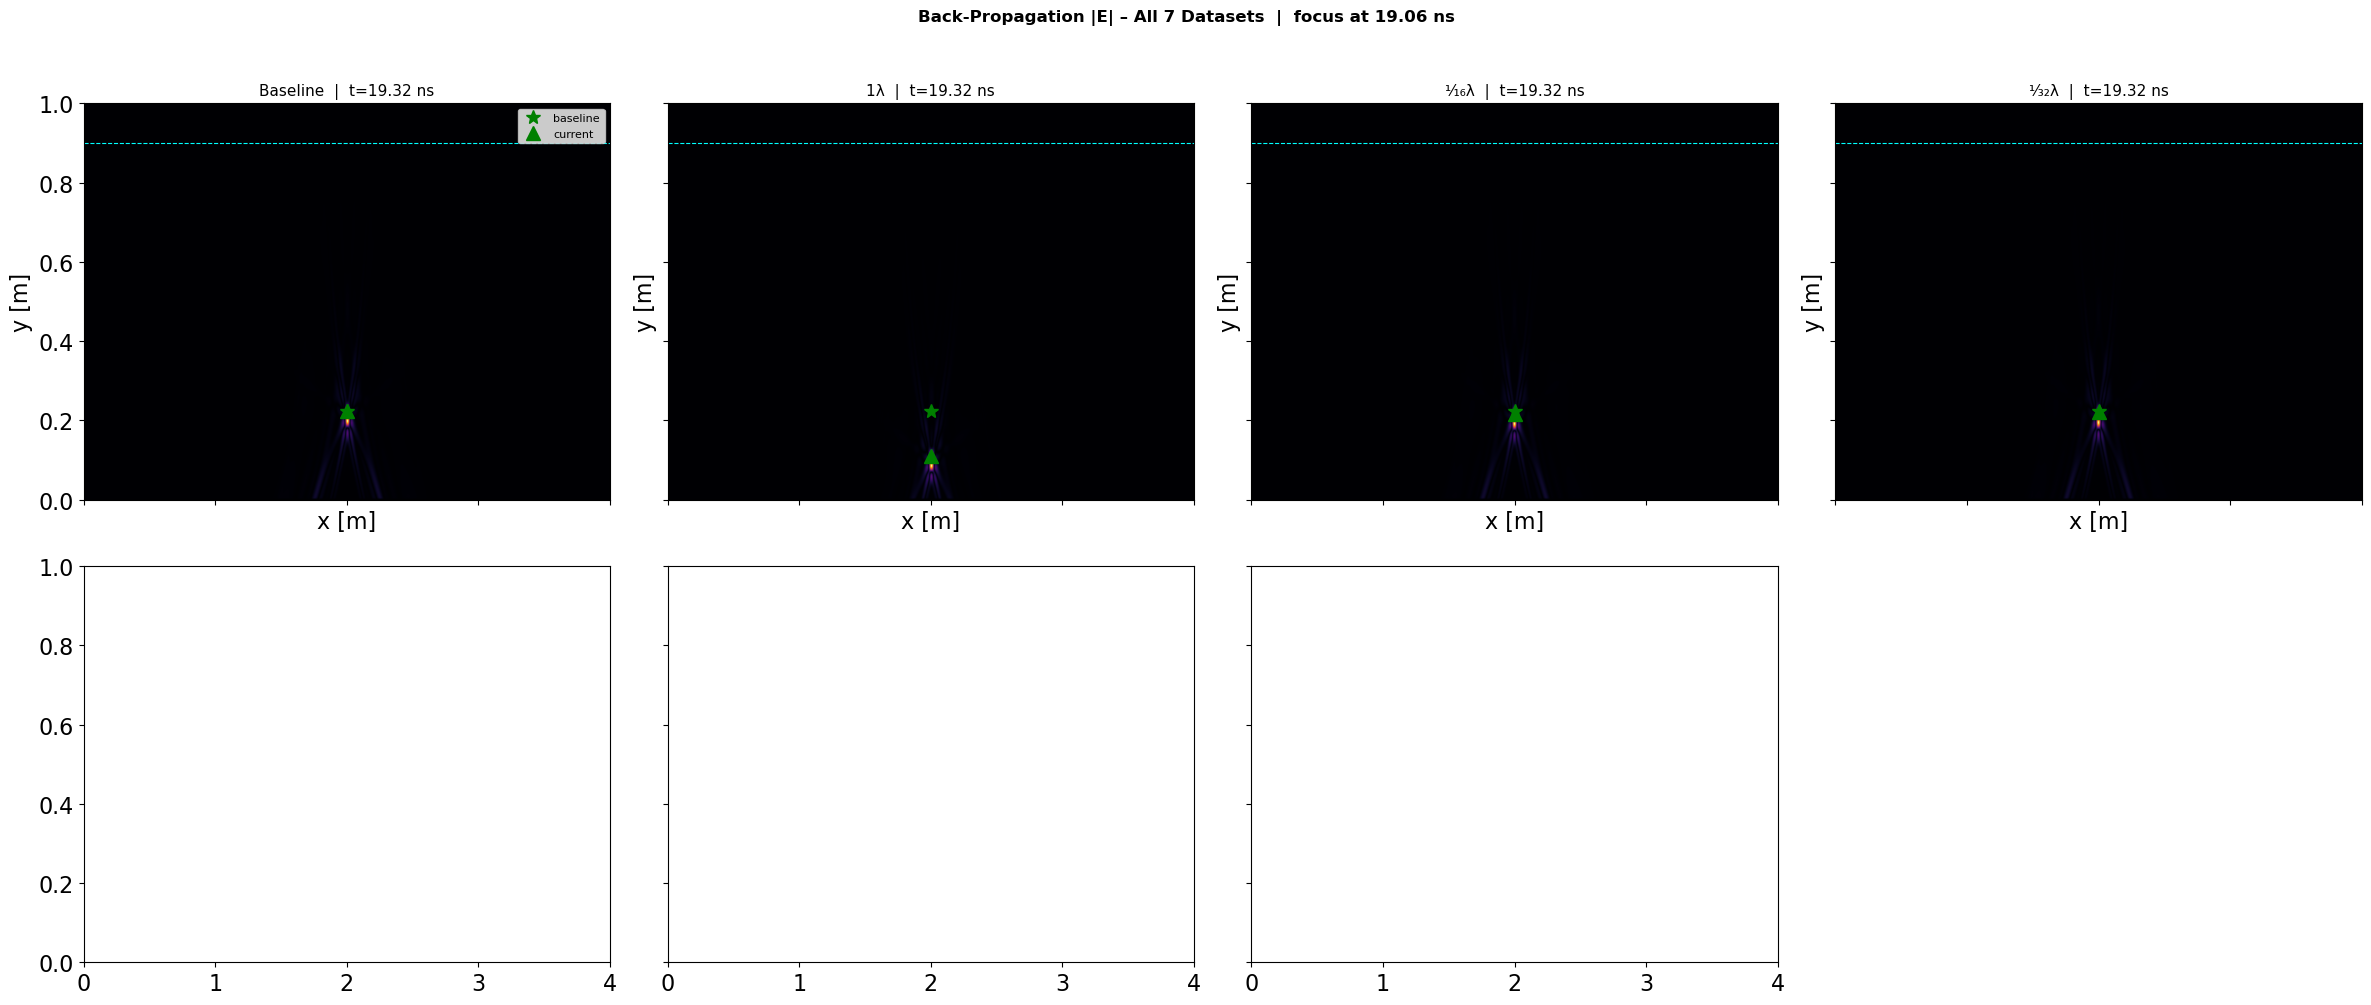

  [saved] VTL_016_Back-Propagation_E_zoomed____focus_at_1906_ns.png


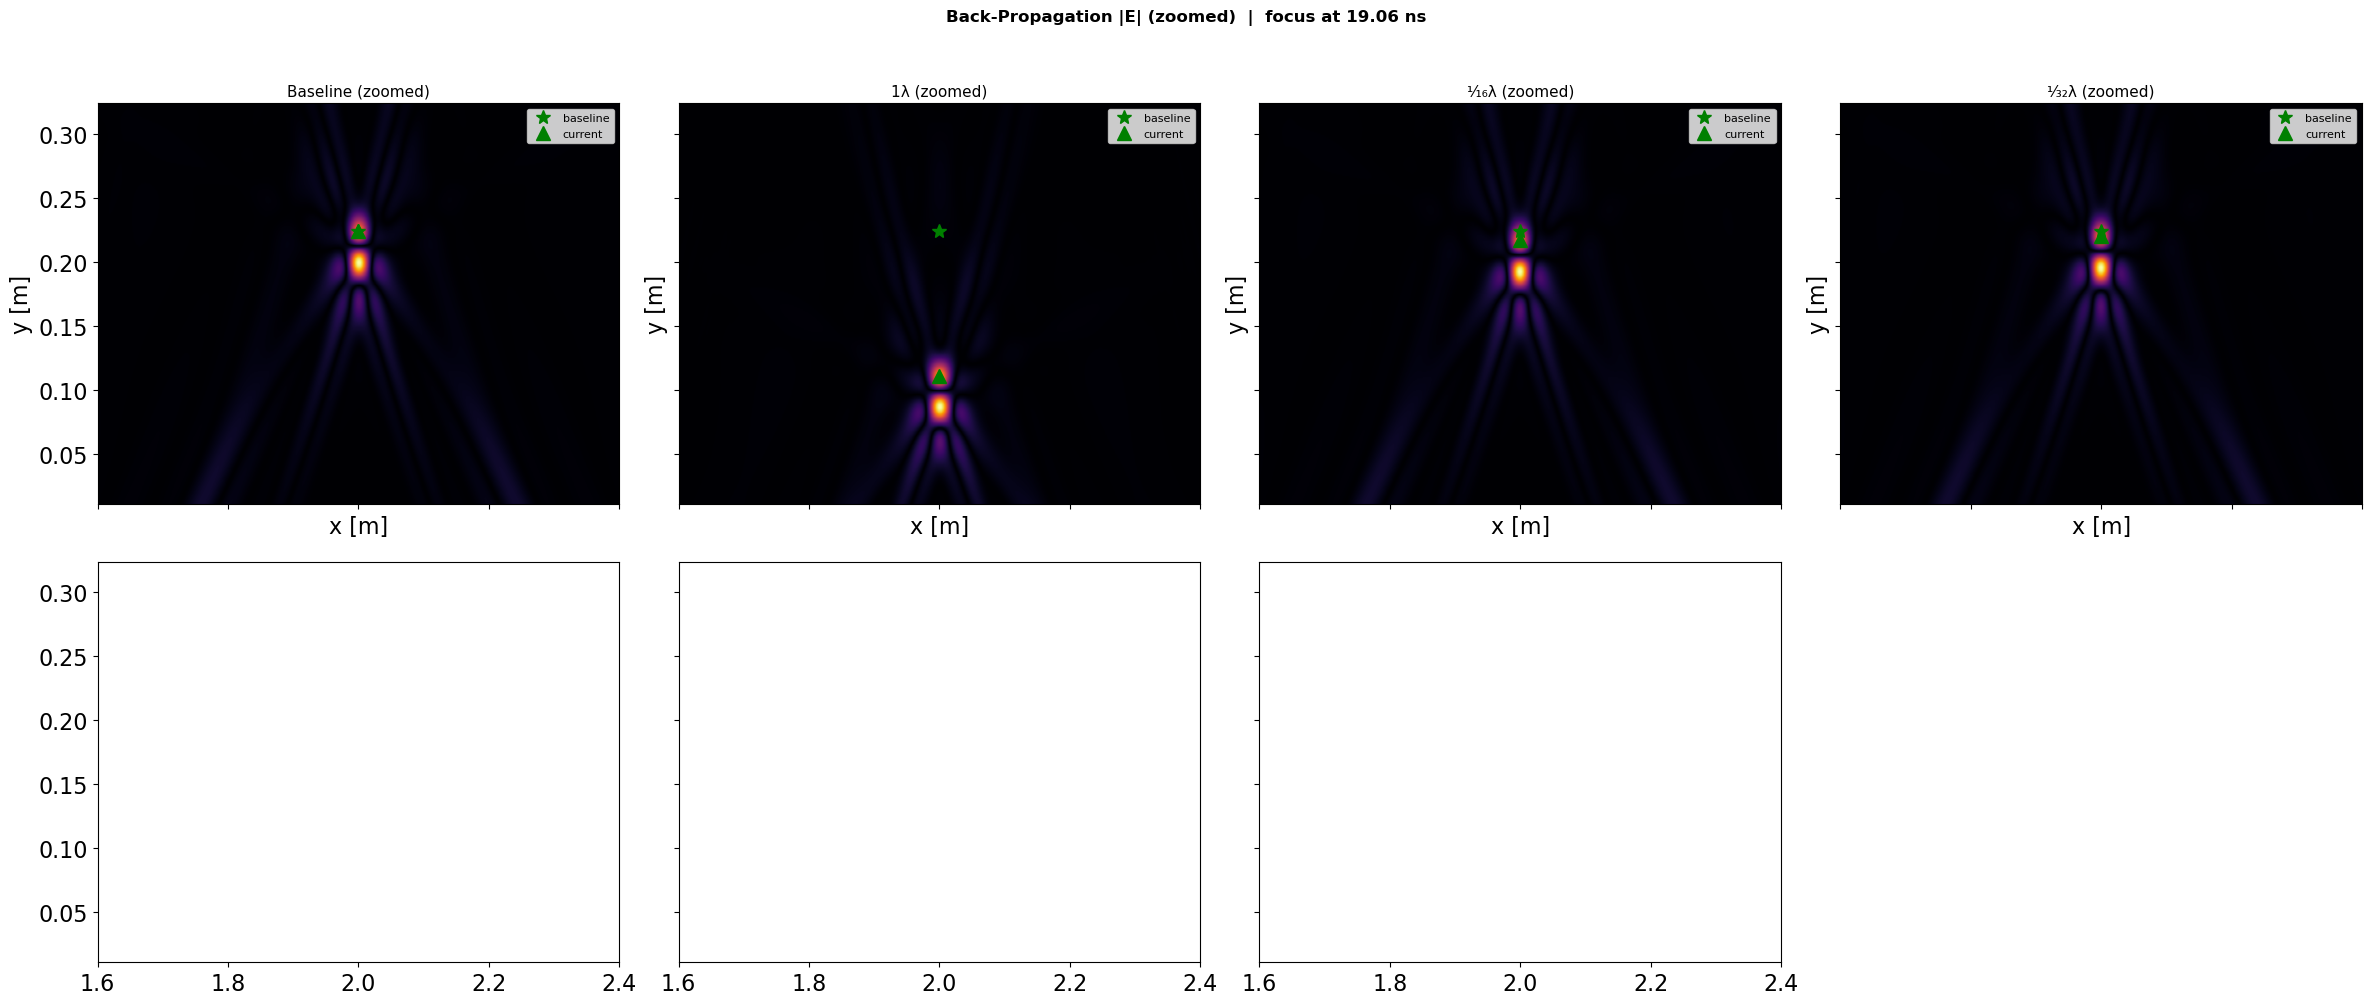

  [saved] VTL_017_Back-Propagation_Ez__All_7_Datasets____focus_at_1906_ns.png


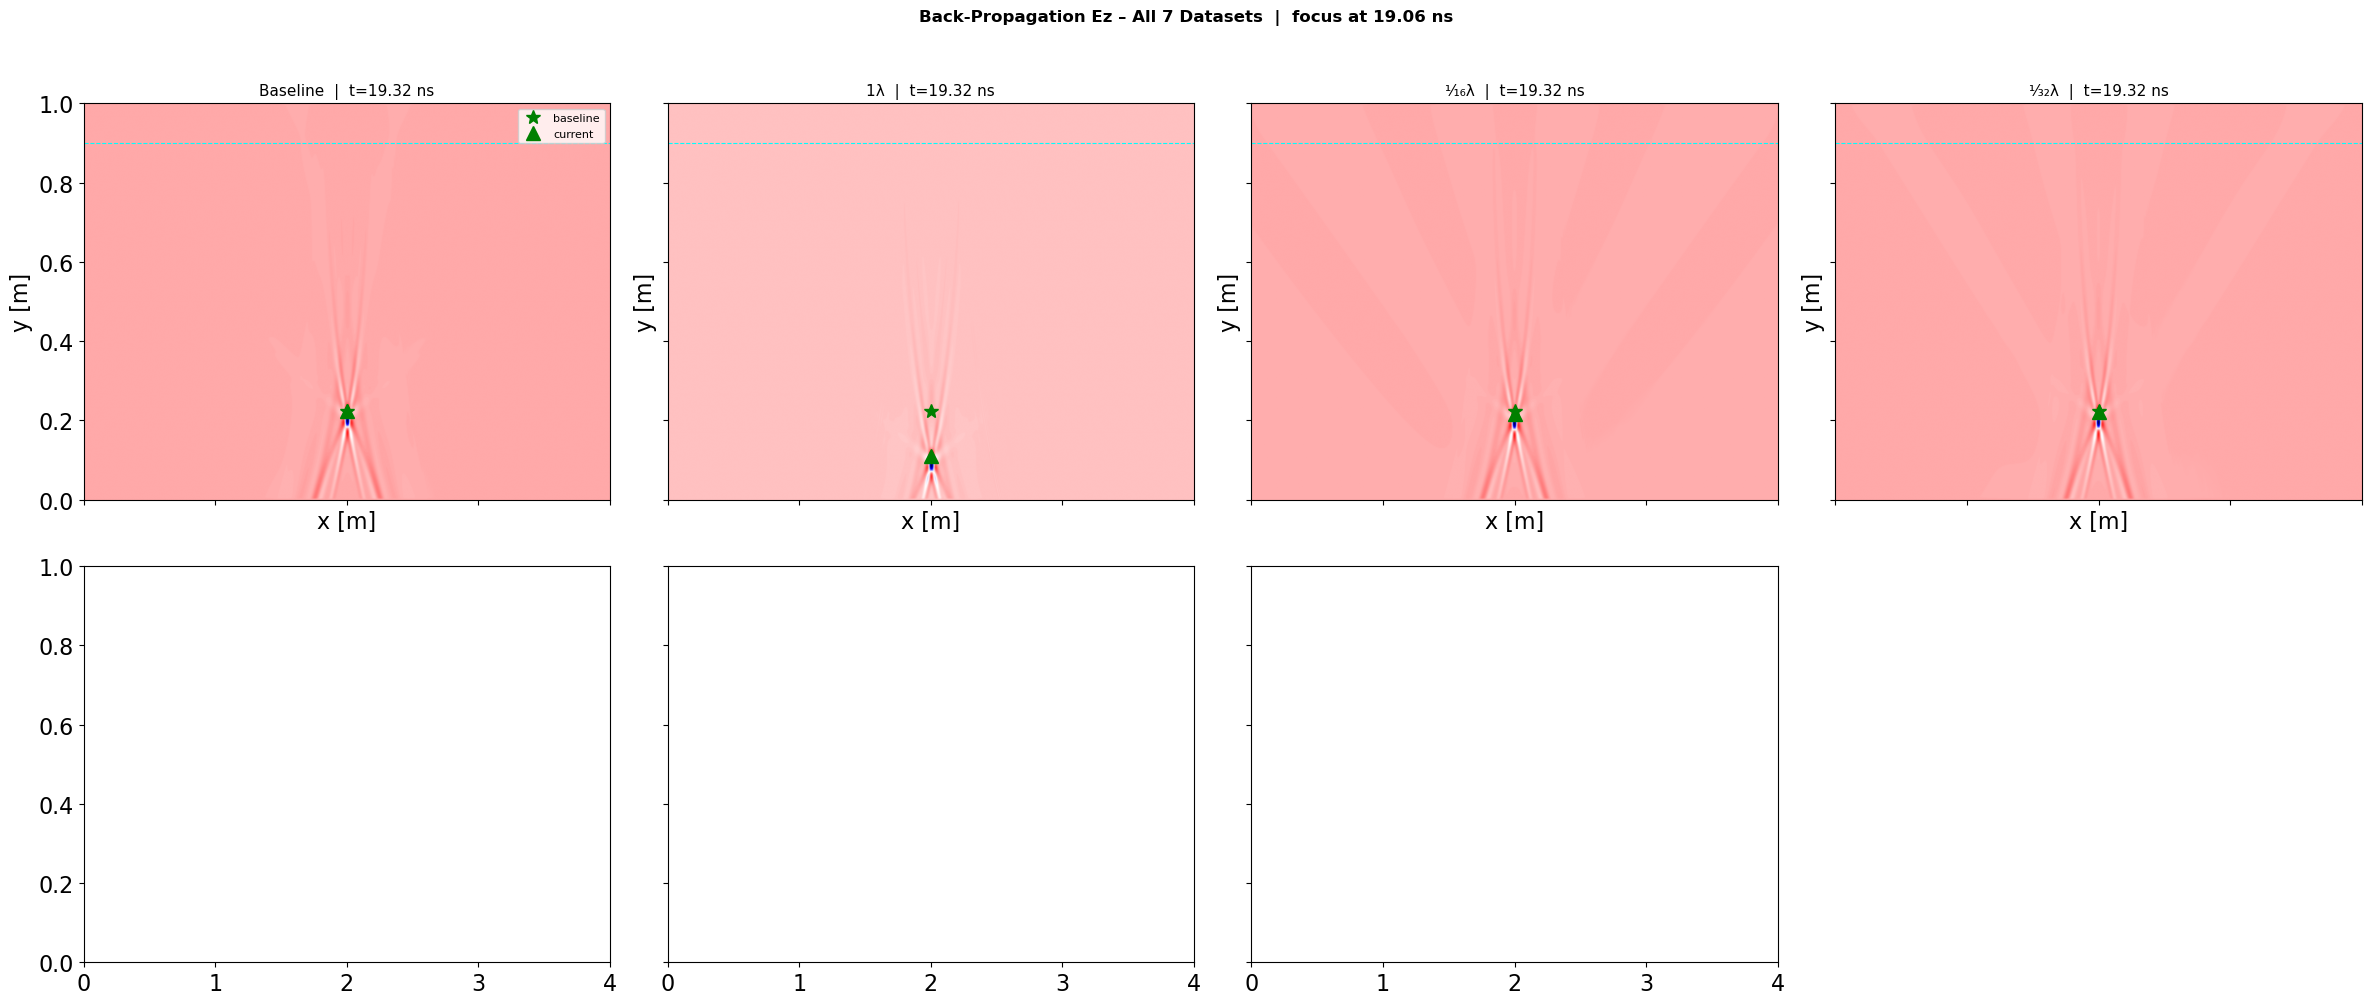

  [saved] VTL_018_Back-Propagation_Ez_zoomed____focus_at_1906_ns.png


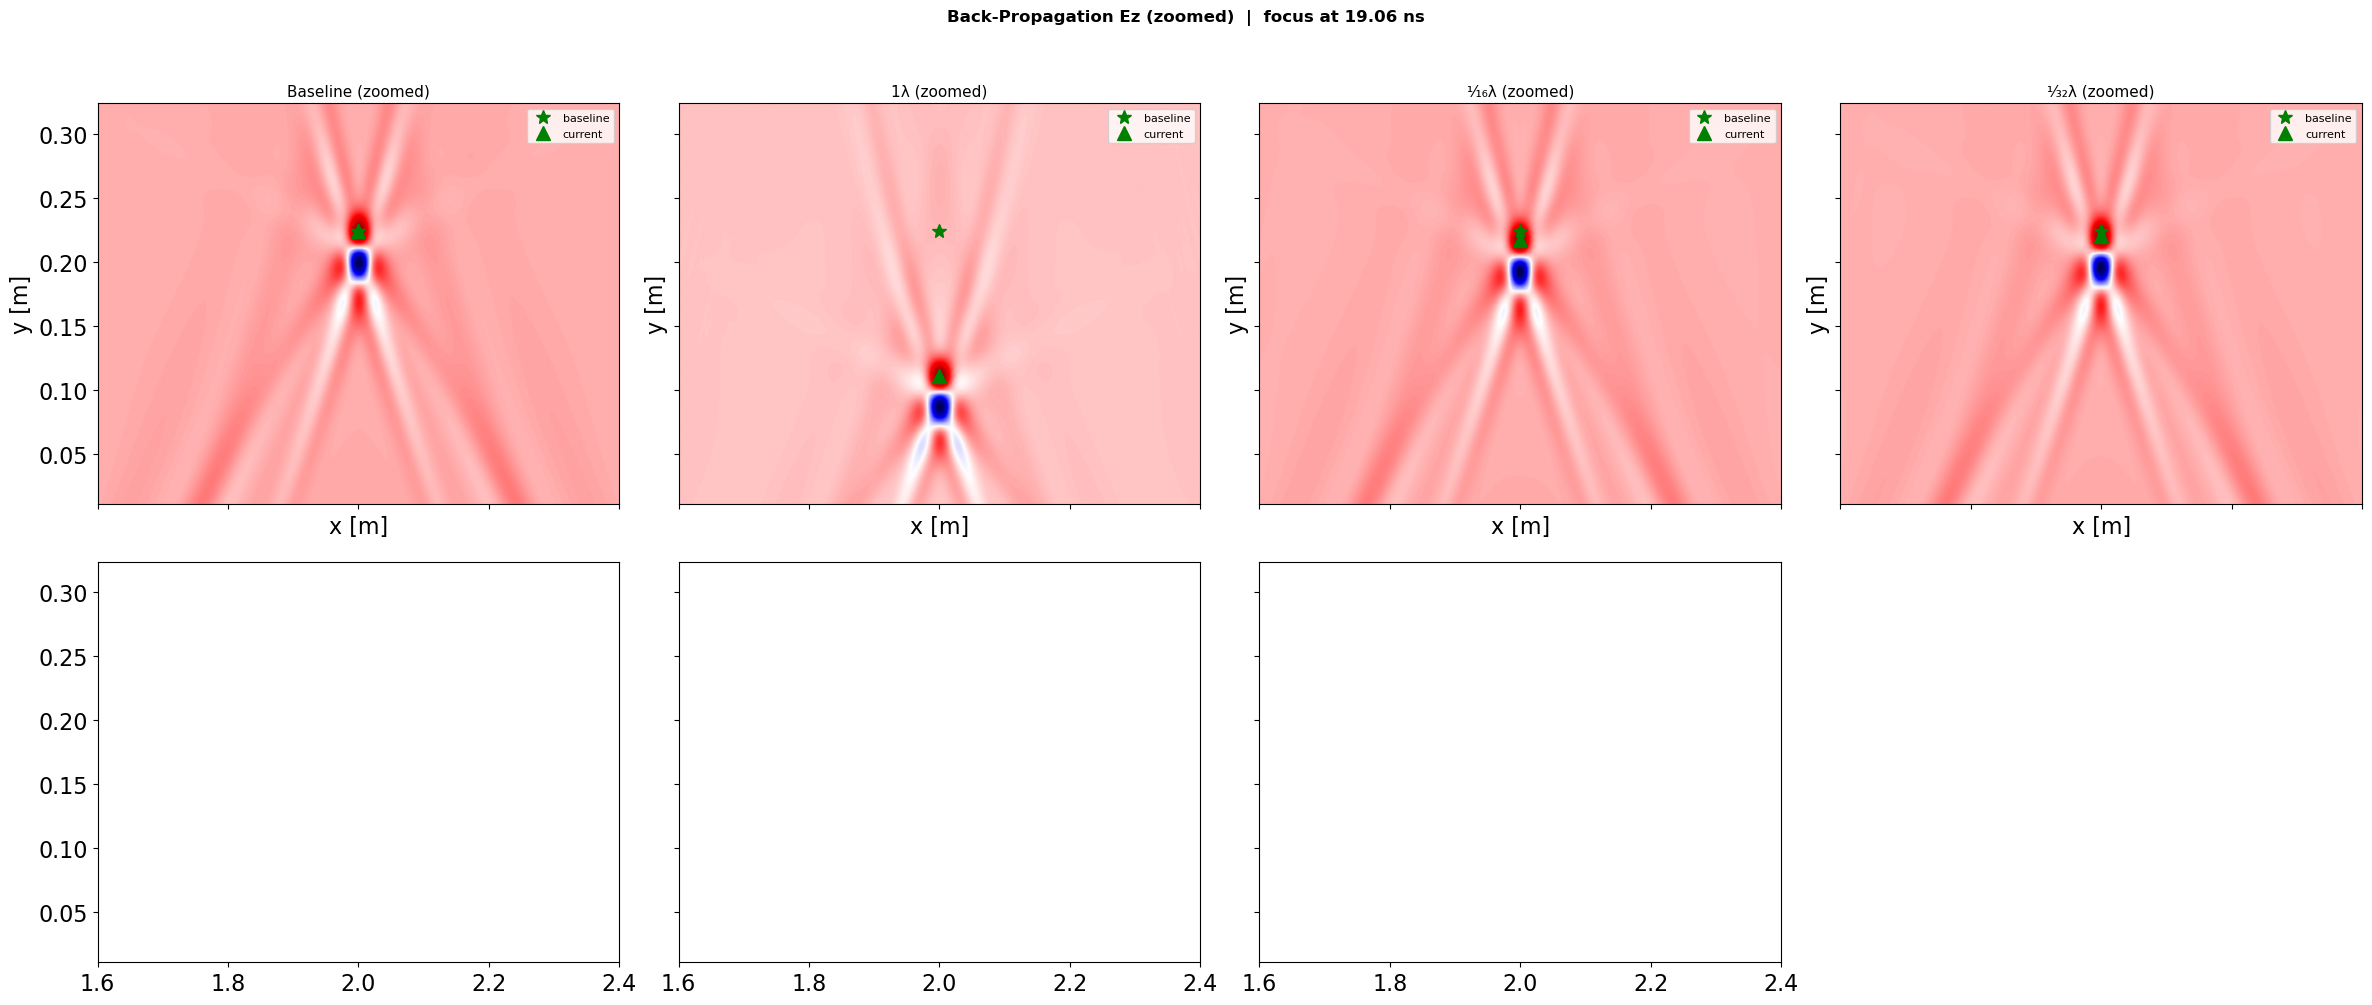

In [29]:
import pyvista

# ── Load focus frame for all 7 datasets ───────────────────────────────────
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames = {}
for i, (label, slug) in enumerate(zip(labels_all, slugs_all)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} – skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 4,
                        len(snap_files) - 1)

    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(1000, 4000))
        snaps_ez.append(e_data[:, 2].reshape(1000, 4000))

    focus_frames[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames[label]["t_actual"]:.3f} ns')

extent_full = [0, 4.0, 0, 1]
margin_x    = 0.4
margin_y    = 0.10
# x-zoom: centred on scatterer
x_zoom_lo = x_scatterer - margin_x
x_zoom_hi = x_scatterer + margin_x
# y-zoom: cover baseline y=0.224 down to 1λ y=0.111, with margin
y_zoom_lo = max(0.0, y_scatterers_shift[0] - margin_y)   # deepest shifted y - margin
y_zoom_hi = y_baseline + margin_y                          # baseline y + margin

def _add_markers_bp(ax, i):
    ax.plot(x_scatterer, y_baseline,             'g*', ms=10, zorder=5, label='baseline')
    ax.plot(x_scatterer, y_all[i], 'g^', ms=10, zorder=5, label='current')

# ── |E| magnitude – full extent ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers_bp(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| – All 7 Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── |E| magnitude – zoomed ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers_bp(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_zoom_lo, y_zoom_hi)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component – full extent ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers_bp(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez – All 7 Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component – zoomed ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers_bp(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_zoom_lo, y_zoom_hi)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

y_all = [y_baseline] + y_scatterers_shift


  [saved] VTL_019_Back-Propagation__TimeLapse_Differences_Ez_Ez__Ez_baseline.png


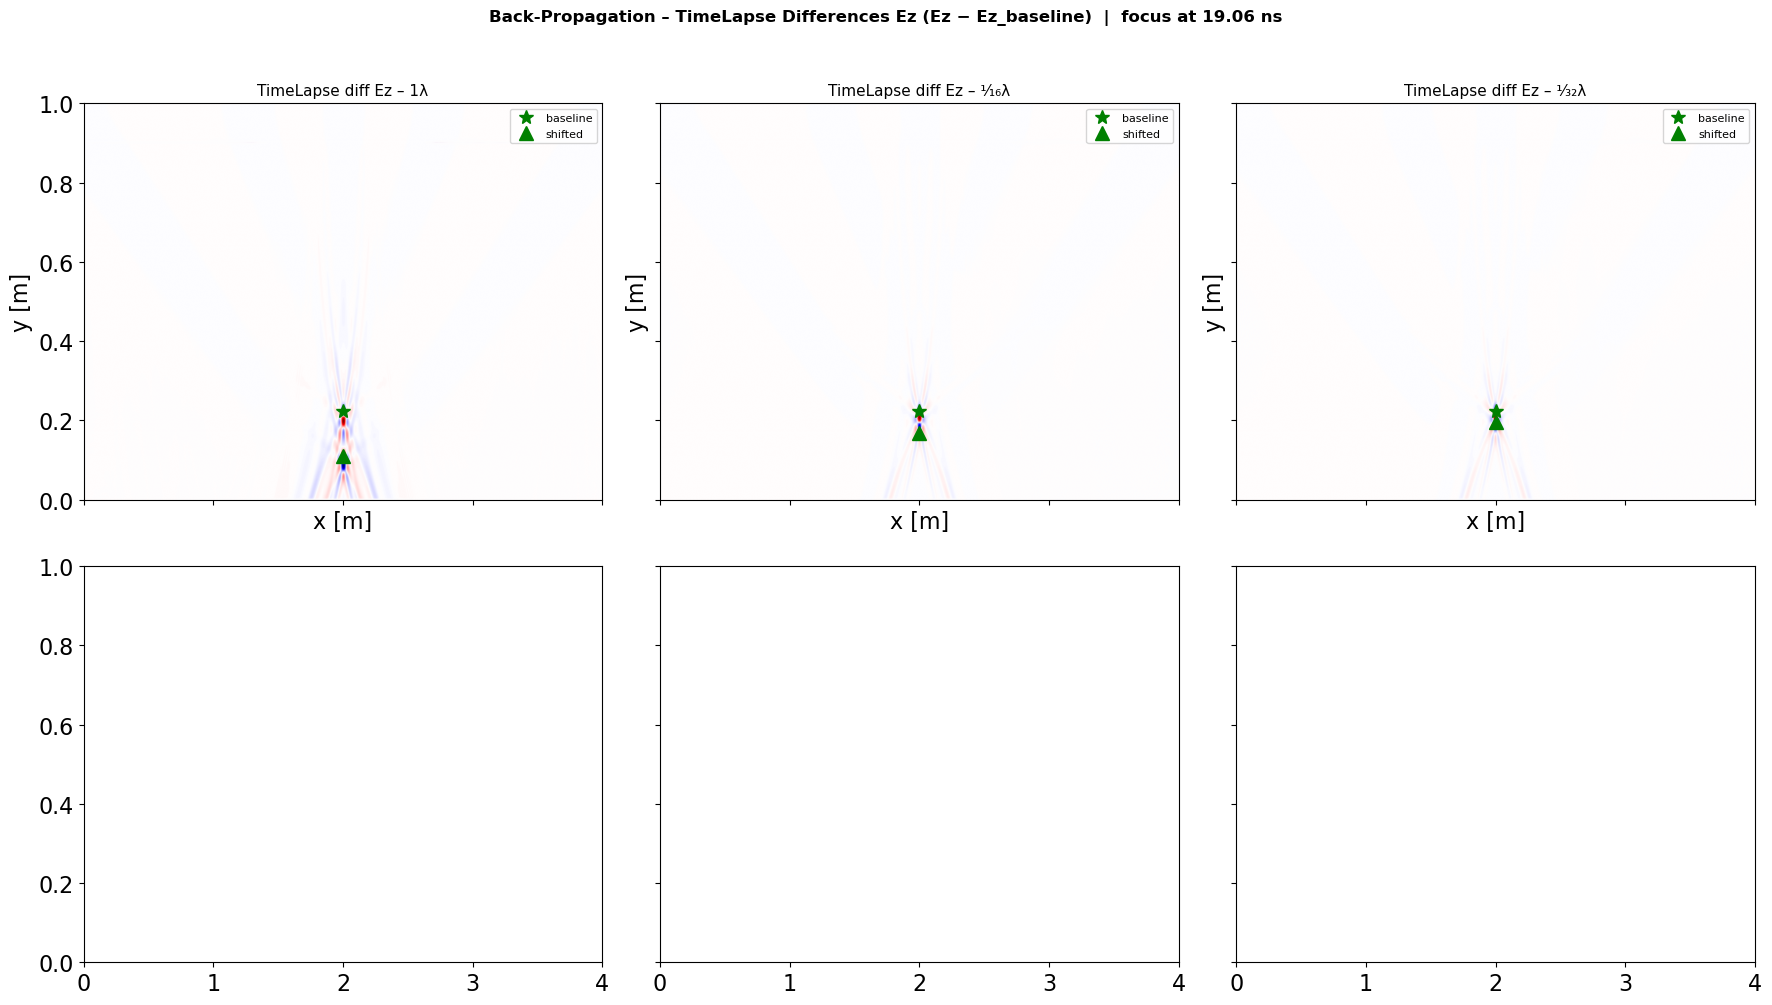

  [saved] VTL_020_Back-Propagation__TimeLapse_Differences_Ez_zoomed.png


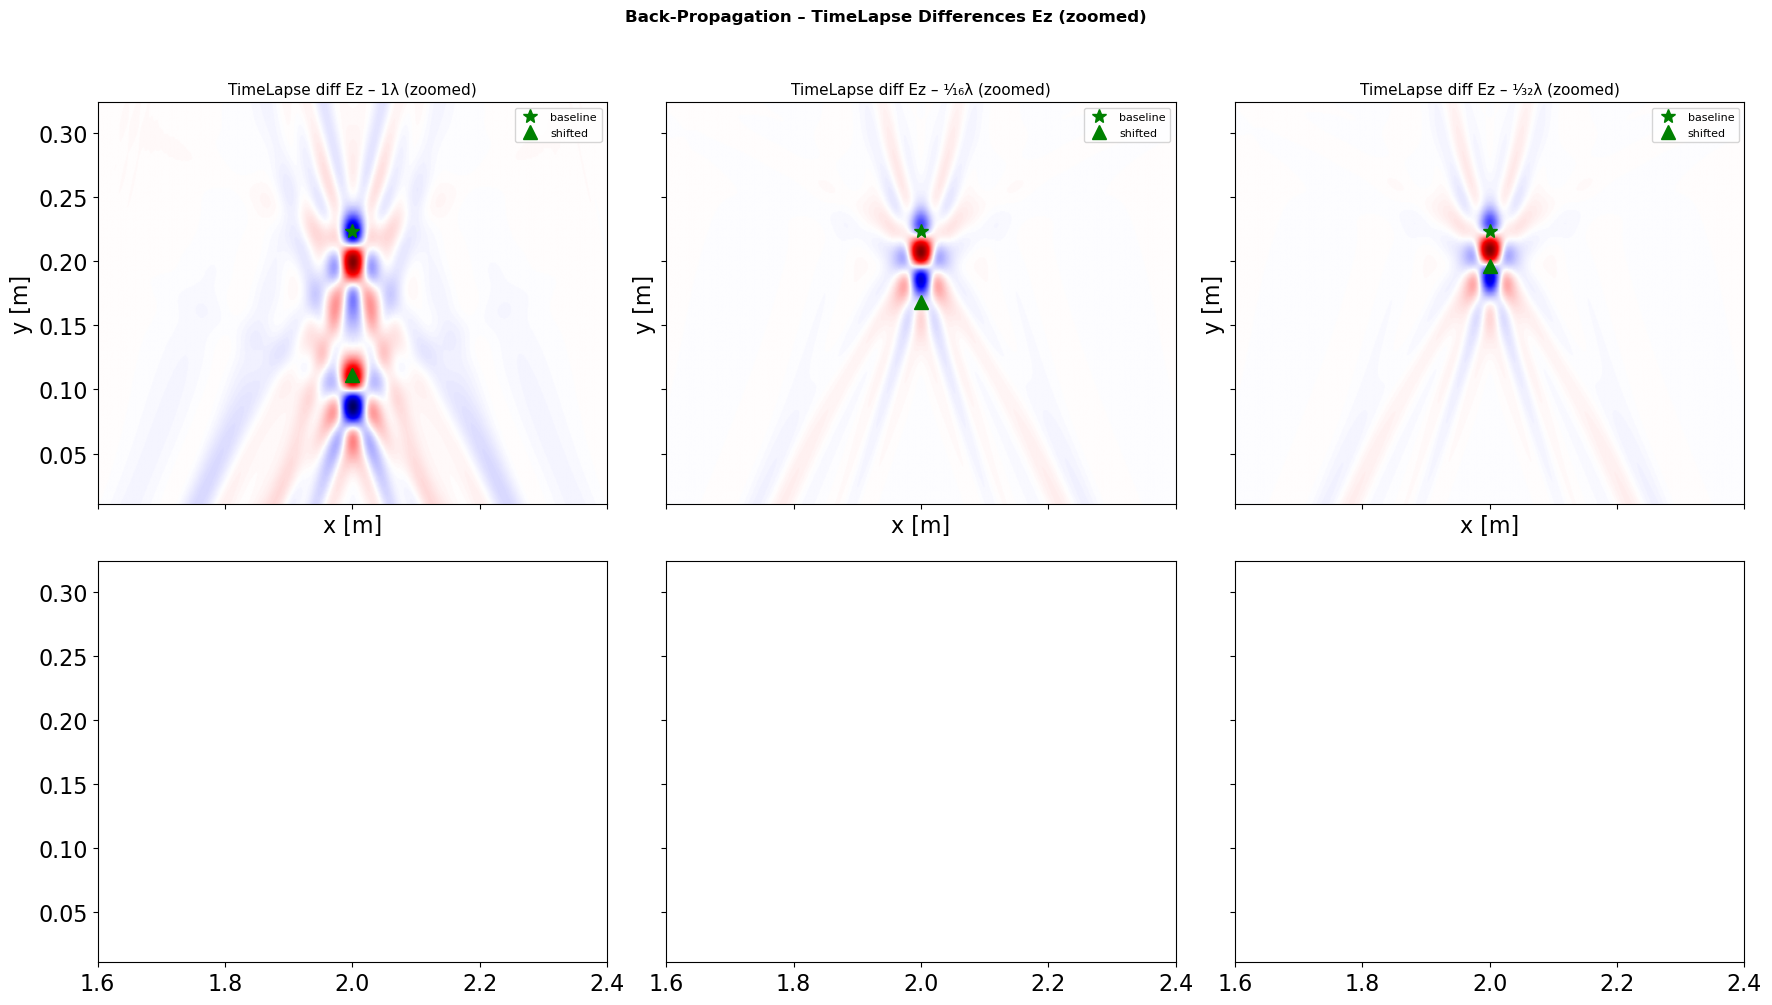

In [30]:
# ── Back-propagation timelapse differences (Ez − Ez_baseline) ────────────
bp_ez_diff = {label: focus_frames[label]['ez'] - focus_frames['Baseline']['ez']
              for label in labels if label in focus_frames}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), bp_ez_diff.items())):
    vmax = np.percentile(np.abs(diff), 100)
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_full, origin='lower')
    ax.plot(x_scatterer, y_baseline,                  'g*', ms=10, zorder=5, label='baseline')
    ax.plot(x_scatterer, y_scatterers_shift[i], 'g^', ms=10, zorder=5, label='shifted')
    ax.set_title(f'TimeLapse diff Ez – {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Back-Propagation – TimeLapse Differences Ez (Ez − Ez_baseline)  |  focus at {t_focus_ns:.2f} ns',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_timelapse_diff_ez.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), bp_ez_diff.items())):
    vmax = np.percentile(np.abs(diff), 100)
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_full, origin='lower')
    ax.plot(x_scatterer, y_baseline,                  'g*', ms=10, zorder=5, label='baseline')
    ax.plot(x_scatterer, y_scatterers_shift[i], 'g^', ms=10, zorder=5, label='shifted')
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_zoom_lo, y_zoom_hi)
    ax.set_title(f'TimeLapse diff Ez – {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle('Back-Propagation – TimeLapse Differences Ez (zoomed)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_timelapse_diff_ez_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# Analysis

[1λ] back-prop diff reprojected  shape=(180, 380)
[½λ] bp_ez_diff missing – skipping
[¼λ] bp_ez_diff missing – skipping
[⅛λ] bp_ez_diff missing – skipping
[¹⁄₁₆λ] back-prop diff reprojected  shape=(180, 380)
[¹⁄₃₂λ] back-prop diff reprojected  shape=(180, 380)
  [saved] VTL_021_Vertical_TimeLapse_Migration_Comparison__Signed_Amplitude.png


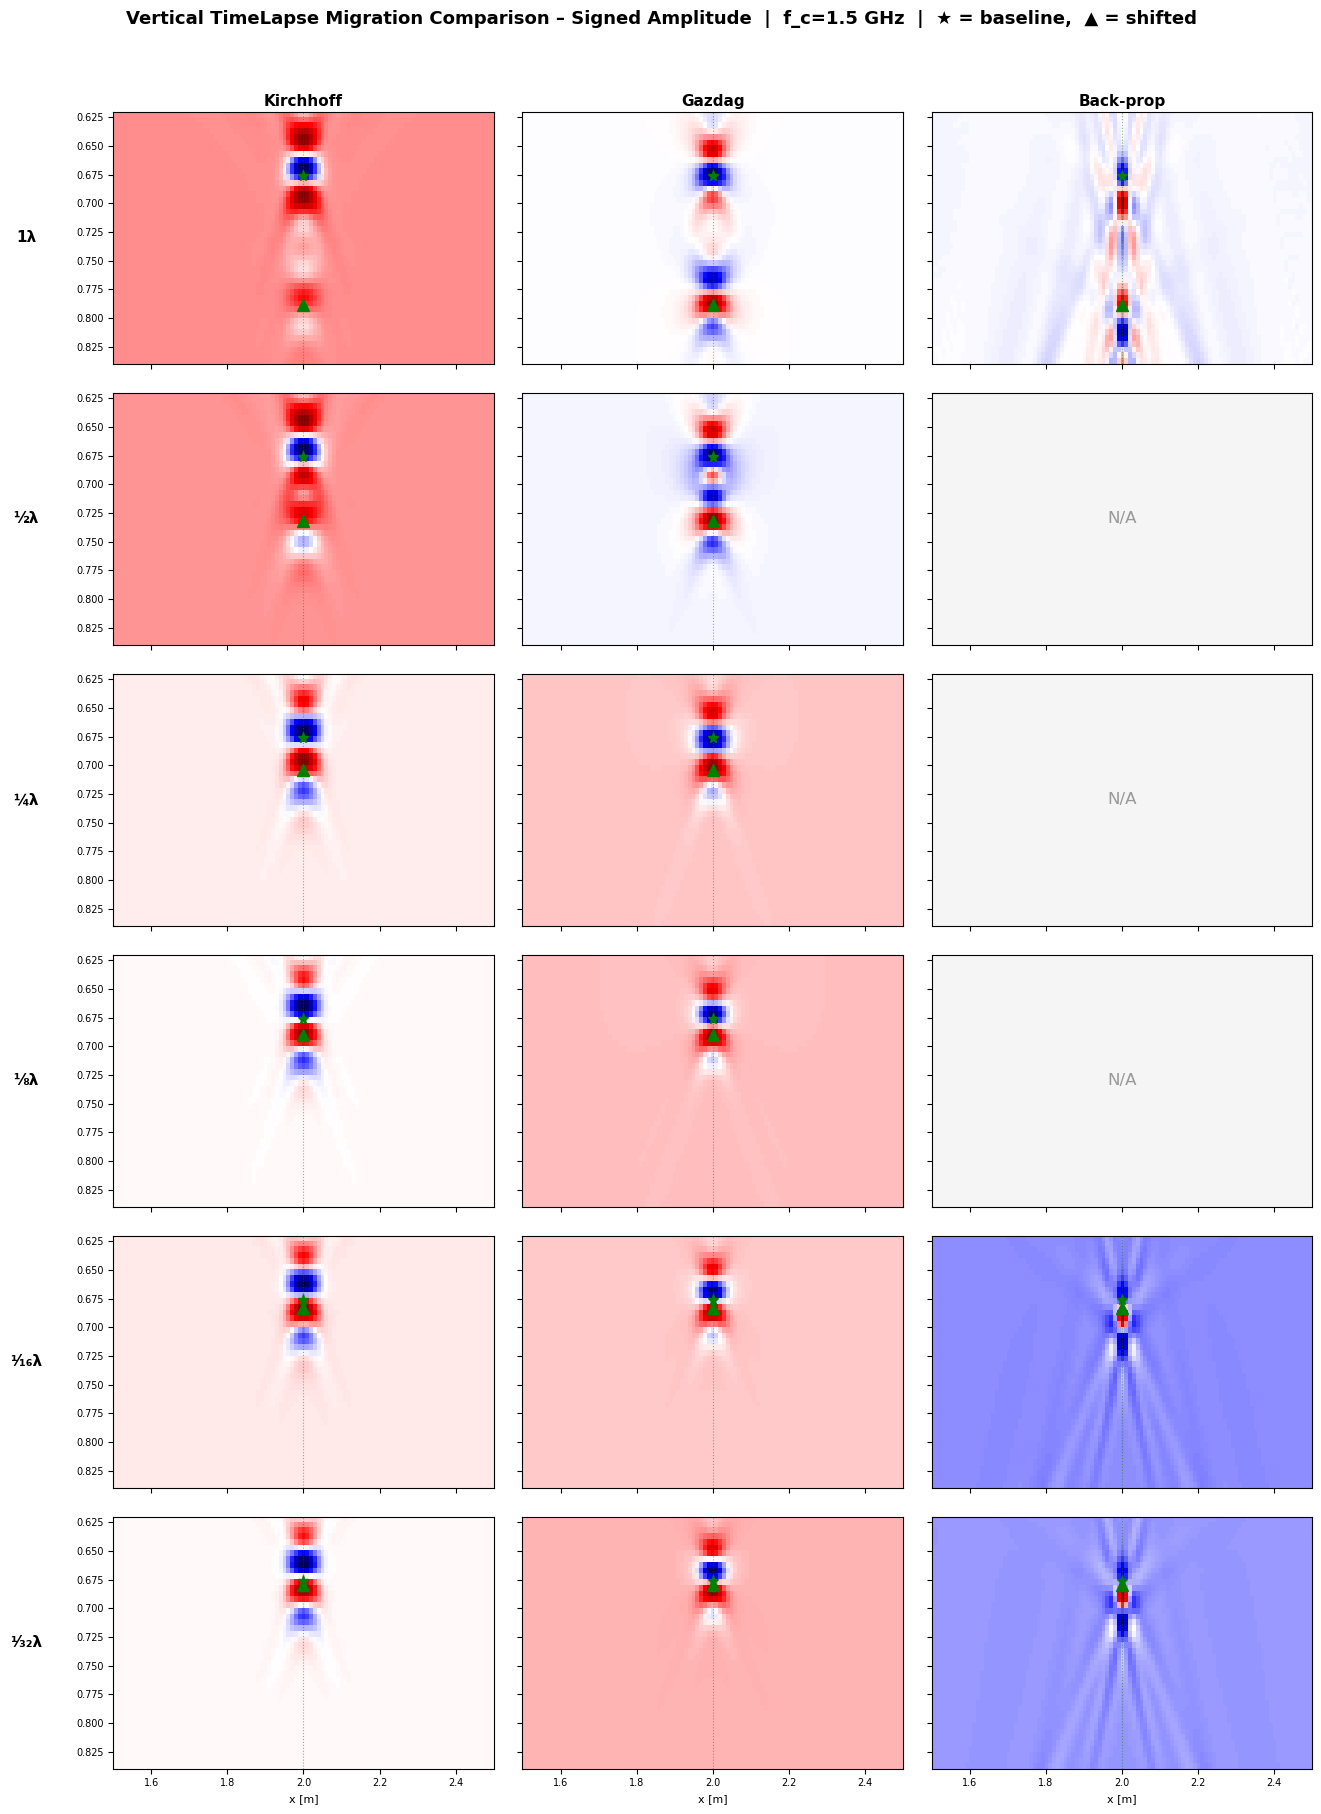

In [31]:
from scipy.signal import hilbert as scipy_hilbert
from scipy.interpolate import RegularGridInterpolator

# ── Collect timelapse difference images ────────────────────────────────────
methods = ['Kirchhoff', 'Gazdag', 'Back-prop']
n_m, n_s = len(methods), len(labels)
imgs = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    try:    imgs[i][0] = migrated_diff[lbl]
    except (KeyError, NameError): pass
    try:    imgs[i][1] = migrated_gz_diff[lbl]
    except (KeyError, NameError): pass

# Back-propagation – reproject bp_ez_diff to migration grid
x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

for i, lbl in enumerate(labels):
    if lbl not in bp_ez_diff:
        print(f'[{lbl}] bp_ez_diff missing – skipping')
        continue
    interp = RegularGridInterpolator(
        (y_ax_bp, x_ax_bp), bp_ez_diff[lbl],
        method='linear', bounds_error=False, fill_value=0.0
    )
    imgs[i][2] = interp((Yq, Xq))
    print(f'[{lbl}] back-prop diff reprojected  shape={imgs[i][2].shape}')

extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
xlim = (1.5, 2.5)
ylim = (0.84, 0.62)

def _comparison_figure(envelope=False):
    fig, axes = plt.subplots(n_s, n_m, figsize=(4.5*n_m, 3.0*n_s),
                             sharex=True, sharey=True)
    for i, lbl in enumerate(labels):
        avail = [imgs[i][j] for j in range(n_m) if imgs[i][j] is not None]
        row_vmax = max(
            np.percentile(np.abs(np.abs(scipy_hilbert(a, axis=0)) if envelope else a), 100)
            for a in avail
        ) if avail else 1.0

        for j, method in enumerate(methods):
            ax  = axes[i, j]
            img = imgs[i][j]

            if i == 0:
                ax.set_title(method, fontsize=11, fontweight='bold', pad=4)
            if j == 0:
                ax.set_ylabel(lbl, fontsize=11, fontweight='bold',
                              rotation=0, labelpad=36, va='center')
            if i == n_s - 1:
                ax.set_xlabel('x [m]', fontsize=8)

            if img is None:
                ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='#999')
                ax.set_facecolor('#f5f5f5')
                continue

            disp = np.abs(scipy_hilbert(img, axis=0)) if envelope else img
            cmap, vmin, vmax = ('hot', 0, row_vmax) if envelope else ('seismic', -row_vmax, row_vmax)

            ax.imshow(disp, aspect='auto', cmap=cmap,
                      extent=extent_mig, origin='upper')
            ax.plot(x_scatterer, z_depths_all[0],     'g*', ms=8, zorder=5, label='baseline')
            ax.plot(x_scatterer, z_depths_all[i + 1], 'g^', ms=8, zorder=5, label='shifted')
            ax.axvline(x_scatterer, color='green', ls=':', lw=0.8, alpha=0.5)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.tick_params(labelsize=7)

    mode = 'Hilbert Envelope' if envelope else 'Signed Amplitude'
    plt.suptitle(
        f'Vertical TimeLapse Migration Comparison – {mode}  |  f_c={f_c_GHz} GHz  '
        f'|  ★ = baseline,  ▲ = shifted',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig

fig1 = _comparison_figure(envelope=False)
fig1.savefig(STUDY_ROOT / 'comparison_timelapse_all_methods.png', dpi=250, bbox_inches='tight')
plt.show()


  [saved] VTL_022_Normalised_Vertical_PSF__TimeLapse_Difference_at_x__20_m.png


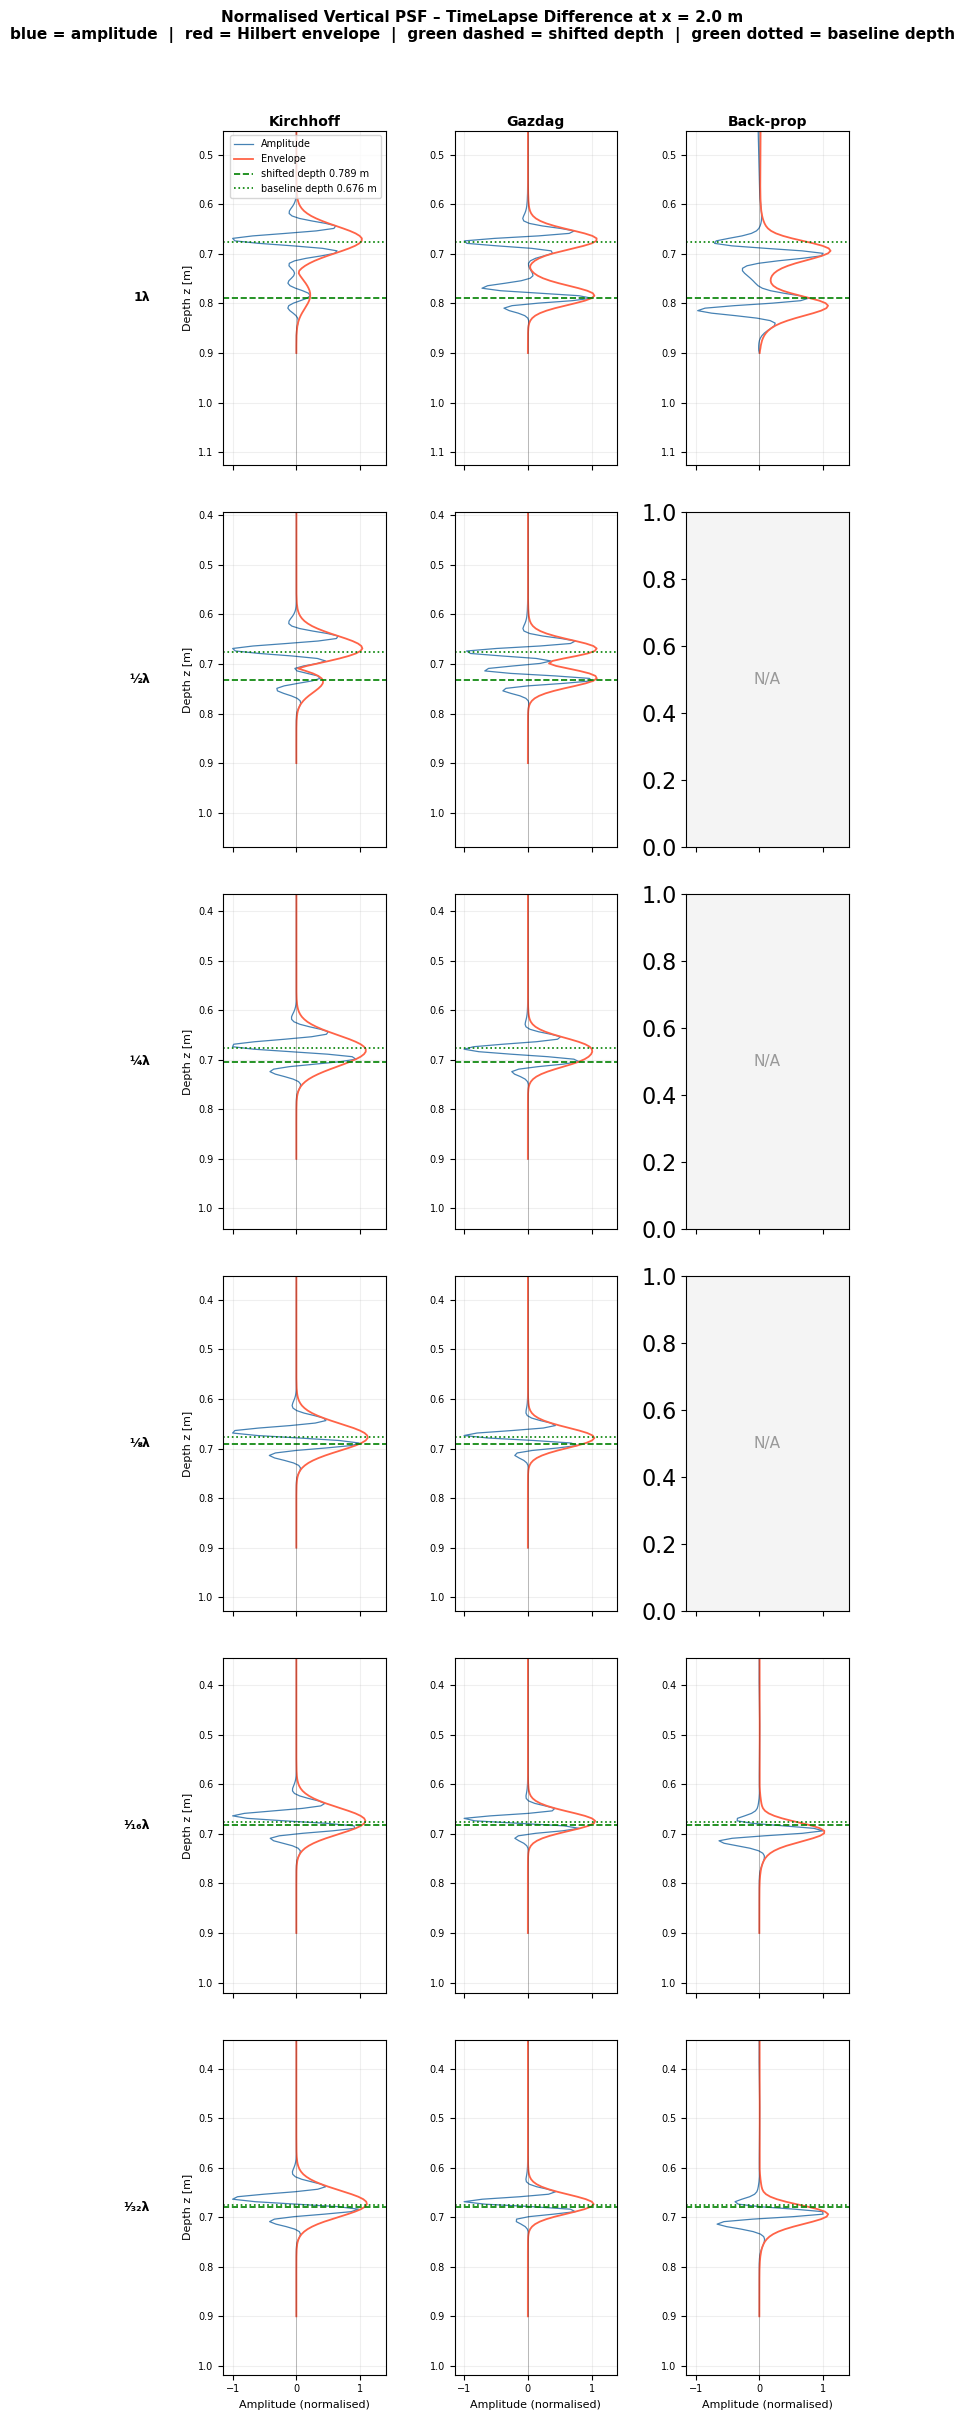

In [32]:
# ── Normalised vertical PSF of timelapse difference at scatterer x-position ──
# Each panel shows the depth profile at x = x_scatterer (x = 2.0 m), with depth
# running vertically down the page (standard depth-profile convention).
# Blue  = signed amplitude (normalised to peak)
# Red   = Hilbert envelope
# Green dashed = shifted depth
# Green dotted  = baseline depth

ix_s = int(np.argmin(np.abs(x_traces - x_scatterer)))   # column index at x = 2.0 m
z_win = 3.0 * wavelength   # half-window in depth around scatterer centre [m]

fig_psf, axes_psf = plt.subplots(n_s, n_m,
                                  figsize=(2.6 * n_m, 4.0 * n_s),
                                  sharex=True)

for i, lbl in enumerate(labels):
    for j, method in enumerate(methods):
        ax  = axes_psf[i, j]
        img = imgs[i][j]

        if i == 0:
            ax.set_title(method, fontsize=10, fontweight='bold', pad=3)
        if j == 0:
            ax.text(-0.45, 0.5, lbl, transform=ax.transAxes, fontsize=9,
                    fontweight='bold', ha='right', va='center')
            ax.set_ylabel('Depth z [m]', fontsize=8)
        if i == n_s - 1:
            ax.set_xlabel('Amplitude (normalised)', fontsize=8)

        if img is None:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                    ha='center', va='center', fontsize=11, color='#999')
            ax.set_facecolor('#f4f4f4')
            continue

        # Vertical profile at x = x_scatterer, normalised to absolute peak
        profile  = img[:, ix_s].copy()
        peak     = np.max(np.abs(profile))
        if peak > 0:
            profile /= peak
        envelope = np.abs(scipy_hilbert(profile))

        ax.plot(profile,  z_img, color='steelblue', lw=0.9, label='Amplitude')
        ax.plot(envelope, z_img, color='tomato',    lw=1.3, label='Envelope')
        ax.axhline(z_depths_all[i + 1], color='green', ls='--', lw=1.2,
                   label=f'shifted depth {z_depths_all[i+1]:.3f} m')
        ax.axhline(z_depths_all[0],     color='green', ls=':',  lw=1.2,
                   label=f'baseline depth {z_depths_all[0]:.3f} m')
        ax.axvline(0, color='k', lw=0.4, alpha=0.4)
        z_centre = z_depths_all[i + 1]
        ax.set_ylim(z_centre + z_win, z_centre - z_win)
        ax.set_xlim(-1.15, 1.4)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

axes_psf[0, 0].legend(fontsize=7, loc='upper right')

plt.suptitle(
    'Normalised Vertical PSF – TimeLapse Difference at x = 2.0 m\n'
    'blue = amplitude  |  red = Hilbert envelope  '
    '|  green dashed = shifted depth  |  green dotted = baseline depth',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'psf_timelapse_vertical_profiles.png', dpi=200, bbox_inches='tight')
plt.show()


# Save Migrated Results as np arrays

In [36]:
# ── Build structured numpy archive of all migrated difference results ──────
_ref_shape = imgs[0][0].shape   # (n_z, n_x)

def _safe_stack(method_idx):
    planes = []
    for i in range(n_s):
        arr = imgs[i][method_idx]
        planes.append(arr.astype(float) if arr is not None
                      else np.full(_ref_shape, np.nan))
    return np.stack(planes, axis=0)

diff_kirchhoff = _safe_stack(0)   # (6, n_z, n_x)
diff_gazdag    = _safe_stack(1)
diff_backprop  = _safe_stack(2)

save_path = STUDY_ROOT / 'vertical_difference_migrated_results.npz'

np.savez_compressed(
    save_path,
    kirchhoff_diff    = diff_kirchhoff,
    gazdag_diff       = diff_gazdag,
    backprop_diff     = diff_backprop,
    scenarios         = np.array(labels,  dtype='U20'),
    methods           = np.array(methods, dtype='U20'),
    shift_lambda      = np.array(shifts_lambda),
    y_scatterers      = np.array(y_scatterers_shift),
    z_depths          = np.array(z_depths_shift),
    x_traces          = x_traces,
    z_img             = z_img,
    x_scatterer       = np.float64(x_scatterer),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f'Saved → {save_path}')
print(f'\nDifference arrays  (n_scenarios={n_s}, n_z={_ref_shape[0]}, n_x={_ref_shape[1]}):')
for name, arr in [('kirchhoff_diff', diff_kirchhoff),
                  ('gazdag_diff',    diff_gazdag),
                  ('backprop_diff',  diff_backprop)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f'  ({absent} scenario(s) absent → NaN)' if absent else ''
    print(f'  {name:<18}  {arr.shape}{note}')


Saved → C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\vertical_difference_migrated_results.npz

Difference arrays  (n_scenarios=6, n_z=180, n_x=380):
  kirchhoff_diff      (6, 180, 380)
  gazdag_diff         (6, 180, 380)
  backprop_diff       (6, 180, 380)  (3 scenario(s) absent → NaN)


In [37]:
# ── Save normal (non-difference) migrated results from all methods ─────────
kirchhoff_all = np.stack([migrated[lbl].astype(float)    for lbl in labels_all], axis=0)  # (7, n_z, n_x)
gazdag_all    = np.stack([migrated_gz[lbl].astype(float) for lbl in labels_all], axis=0)

x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

from scipy.interpolate import RegularGridInterpolator as _RGI
backprop_planes = []
for lbl in labels_all:
    if lbl in focus_frames:
        interp = _RGI((y_ax_bp, x_ax_bp), focus_frames[lbl]['ez'],
                      method='linear', bounds_error=False, fill_value=0.0)
        backprop_planes.append(interp((Yq, Xq)).astype(float))
    else:
        backprop_planes.append(np.full((len(z_img), len(x_traces)), np.nan))
        print(f'[{lbl}] focus_frames missing – filled with NaN')
backprop_all = np.stack(backprop_planes, axis=0)   # (7, n_z, n_x)

save_path_mig = STUDY_ROOT / 'vertical_migrated_results.npz'
np.savez_compressed(
    save_path_mig,
    kirchhoff         = kirchhoff_all,
    gazdag            = gazdag_all,
    backprop          = backprop_all,
    scenarios         = np.array(labels_all, dtype='U20'),
    shift_lambda      = np.array([0] + shifts_lambda),
    y_scatterers      = np.array([y_baseline] + y_scatterers_shift),
    z_depths          = np.array([z_scatterer] + z_depths_shift),
    x_traces          = x_traces,
    z_img             = z_img,
    x_scatterer       = np.float64(x_scatterer),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f'Saved → {save_path_mig}')
print(f'\nStacked arrays  (n_scenarios=7, n_z={kirchhoff_all.shape[1]}, n_x={kirchhoff_all.shape[2]}):')
for name, arr in [('kirchhoff', kirchhoff_all), ('gazdag', gazdag_all), ('backprop', backprop_all)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f'  ({absent} absent → NaN)' if absent else ''
    print(f'  {name:<12}  {arr.shape}{note}')


[½λ] focus_frames missing – filled with NaN
[¼λ] focus_frames missing – filled with NaN
[⅛λ] focus_frames missing – filled with NaN


Saved → C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\vertical_timelapse_study\vertical_migrated_results.npz

Stacked arrays  (n_scenarios=7, n_z=180, n_x=380):
  kirchhoff     (7, 180, 380)
  gazdag        (7, 180, 380)
  backprop      (7, 180, 380)  (3 absent → NaN)
